# Import packages

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import PredictionErrorDisplay

from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.pipeline import Pipeline


In [ ]:
# uncomment when using Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

# Export directory

In [52]:
export_dir = r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\TSS Modeling'

# Import data

In [53]:
# import directory
data_directory = r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Landsat Sampling\Merged Landsat Data'

In [54]:
# import data as dataframe
df = pd.read_csv(os.path.join(data_directory,'min_date.csv'))
df = df.drop(columns=['Unnamed: 0', 'CHLOROPHYLL',  
                      'CHLOROPHYLL_B', 'DOC', 'dif_date_point',
                      'N_TOTAL', 'N_TOTAL_DISSOLVED', 
                      'POC', 'P_ORGANIC', 'P_TOTAL', 
                      'SILICA',  'TOC', 'duplicated'],axis=1).rename(columns={'SPM':"TSS"})
df.columns

Index(['CHLOROPHYLL_A', 'CLOUD_COVER', 'DEPTH_CLASS', 'ID', 'LATITUDE',
       'LOCATION', 'LONGITUDE', 'MISSION', 'SAMPLE_SITE', 'SAMPLING_DEPTH',
       'TSS', 'TOTAL_DEPTH', 'TURBIDITY', 'WATER_PERIOD', 'blue_max',
       'blue_mean', 'blue_median', 'blue_min', 'blue_stdDev', 'count_pixel',
       'datetime', 'green_max', 'green_mean', 'green_median', 'green_min',
       'green_stdDev', 'img_date', 'nir_max', 'nir_mean', 'nir_median',
       'nir_min', 'nir_stdDev', 'red_max', 'red_mean', 'red_median', 'red_min',
       'red_stdDev', 'system_index', 'dif_date_point_abs', 'satellite'],
      dtype='object')

# Model Evaluation Functions

In [55]:
def model_metrics(y_true,y_pred):
    ''' y = observed target values
    y_pred = predicted target values'''
    from sklearn.metrics import r2_score
    from sklearn.metrics import mean_absolute_error
    from sklearn.metrics import mean_squared_error
    from sklearn.metrics import mean_absolute_percentage_error
    from sklearn.metrics import explained_variance_score

    return {'r2':r2_score(y_true, y_pred),
'mae':mean_absolute_error(y_true, y_pred),
'mse':mean_squared_error(y_true, y_pred),
'mape':mean_absolute_percentage_error(y_true, y_pred),
'exp_var': explained_variance_score(y_true, y_pred)
    }

In [56]:
def cv_model_metrics(model,X,y,n_cv=20):
    ''' model = model to evaluate
    X = predictors
    y = observed target values
    cv = number of cross validations, standard is 5'''
    from sklearn.model_selection import ShuffleSplit

    cv = ShuffleSplit(n_splits=n_cv, test_size=0.15, random_state=0)
    from sklearn.model_selection import cross_val_score

    return {'r2':float(abs(cross_val_score(model, X, y, cv=cv,scoring='r2')).mean()),
'mae':float(abs(cross_val_score(model, X, y, cv=cv,scoring='neg_mean_absolute_error')).mean()),
'mse':float(abs(cross_val_score(model, X, y, cv=cv,scoring='neg_mean_squared_error')).mean()),
'mape':float(abs(cross_val_score(model, X, y, cv=cv,scoring='neg_mean_absolute_percentage_error')).mean()),
'exp_var':float( abs(cross_val_score(model, X, y, cv=cv,scoring='explained_variance')).mean())
    }

# Helper functions

**Helper Functions**
1. **`plot_evaluation()`** - Standardizes residual and prediction error plots
2. **`prepare_time_series_plot()`** - Creates consistent time-series visualizations with metrics
3. **`train_and_evaluate_model()`** - Unified training, evaluation, and plotting pipeline
4. **`batch_model_evaluation()`** - Batch processes multiple datasets with same model

In [57]:
def plot_evaluation(y_true, y_pred, title="Model Evaluation"):
    """Create residual and prediction error plots."""
    fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
    PredictionErrorDisplay.from_predictions(
        y_true,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=axs[0]
    )
    axs[0].set_title("Actual vs. Predicted values")
    PredictionErrorDisplay.from_predictions(
        y_true,
        y_pred=y_pred,
        kind="residual_vs_predicted",
        ax=axs[1]
    )
    axs[1].set_title("Residuals vs. Predicted Values")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [58]:
def prepare_time_series_plot(df, y_pred, cv_metrics_dict, title, r2_key='r2'):
    """Create time series plot with predictions and observations."""
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Plot predictions
    ax.plot(df['datetime'], y_pred, 
            color='gray', marker='x', linestyle='solid', linewidth=2, label='Predicted Model')
    
    # Define colors for water periods
    water_periods = sorted(df['WATER_PERIOD'].unique())
    color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}
    
    # Plot observations by water period
    for water_period in water_periods:
        subset = df[df['WATER_PERIOD'] == water_period]
        ax.plot(subset['datetime'], subset['TSS'],
                marker='o', markersize=6, alpha=0.5, 
                color=colors[water_period], linestyle='none',
                label=f'{water_period}')
    
    # Add metrics text box
    if cv_metrics_dict and r2_key in cv_metrics_dict:
        r2 = round(float(cv_metrics_dict[r2_key]), 4)
        r2_str = f'$R^2$ = {r2}'
        ax.text(0.05, 0.95, r2_str, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    ax.set_xlabel('Date')
    ax.set_ylabel('TSS (mg/L)')
    ax.set_title(title)
    ax.legend(loc='upper right')

   
    # Set x-ticks
    total_len = len(y_pred)
    ticks = np.arange(0, total_len, 20)
    tick_labels = [df['date'].iloc[t] if t < len(df) else '' for t in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)
    
    plt.tight_layout()
    plt.show()

In [59]:
def train_and_evaluate_model(model, X, y, model_name, df_data=None, title=None):
    """Train model, evaluate, and optionally plot results."""
    # Fit and predict
    model_fit = model.fit(X, y)
    y_pred = model_fit.predict(X)
    
    # Calculate metrics
    metrics = model_metrics(y, y_pred)
    cv_metrics = cv_model_metrics(model, X, y, n_cv=20)
    
    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")
    print(f"Training Metrics: {metrics}")
    print(f"CV Metrics: {cv_metrics}")
    
    # Plot evaluation
    plot_evaluation(y, y_pred, title=f"{model_name} - Model Evaluation")
    
    # Plot time series if data provided
    if df_data is not None and title is not None:
        prepare_time_series_plot(df_data, y_pred, cv_metrics, title)
    
    return model_fit, y_pred, metrics, cv_metrics

In [60]:
def batch_model_evaluation(df_list, target_col, feature_cols, model, model_name, periods=None):
    """
    Batch evaluate model across multiple datasets (e.g., water periods).
    
    Parameters:
    -----------
    df_list : list of DataFrames
    target_col : str, column name for target variable
    feature_cols : list of str, column names for features
    model : sklearn model or pipeline
    model_name : str, name for logging
    periods : list, names corresponding to each df
    
    Returns:
    --------
    dict with results for each period
    """
    results = {}
    
    for i, dataset in enumerate(df_list):
        period_name = periods[i] if periods else f"Period_{i}"
        
        y = dataset[target_col].copy()
        X = dataset[feature_cols].copy()
        
        model_fit, y_pred, metrics, cv_metrics = train_and_evaluate_model(
            model, X, y, f"{model_name} - {period_name}"
        )
        
        results[period_name] = {
            'model': model_fit,
            'predictions': y_pred,
            'metrics': metrics,
            'cv_metrics': cv_metrics,
            'X': X,
            'y': y
        }
    
    return results

# Model Configuration

In [61]:
# Central model definitions
MODEL_CONFIG = {
    'ols': {
        'model': LinearRegression(),
        'description': 'Ordinary Least Squares'
    },
    'polynomial2': {
        'model': Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('linear', LinearRegression(positive=False))
        ]),
        'description': '2nd Degree Polynomial'
    },
    'polynomial3': {
        'model': Pipeline([
            ('poly', PolynomialFeatures(degree=3, include_bias=False)),
            ('linear', LinearRegression(positive=False))
        ]),
        'description': '3rd Degree Polynomial'
    },
    'splines': {
        'model': Pipeline([
            ('spline', SplineTransformer(n_knots=5, degree=3)),
            ('linear', LinearRegression(positive=False))
        ]),
        'description': 'Spline Transformation'
    }
}

In [62]:
def get_model(model_name):
    """
    Get model by name.
    Usage
    model_poly = get_model('polynomial')
    model_splines = get_model('splines')
    """
    return MODEL_CONFIG[model_name]['model']

In [82]:
FEATURE_GROUPS = {
    'single_band': {
        'nir': {'band': ['nir_mean'],
                'name': 'NIR'},
        'red': {'band': ['red_mean'],
                'name': 'RED'},
        'green': {'band': ['green_mean'],
                  'name': 'GREEN'},
        'blue': {'band': ['blue_mean'],
                 'name': 'BLUE'},
        'nir_red_ratio': {'band': ['nir_red_ratio'],
                          'name': 'NIR/RED ratio'},
        'red_nir_ratio': {'band': ['red_nir_ratio'],
                          'name': 'RED/NIR ratio'}
    },
    'multi_band': {
        'nir_red': {'band': ['nir_mean', 'red_mean'],
                    'name': 'NIR and RED'},
        'all_bands': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean'],
                      'name': 'All bands'}
    }
}

# Usage
# X_nir_red = df_subset[FEATURE_GROUPS['multi_band']['nir_red']]

# Cross-Validation Settings

In [64]:
# CV Configuration
CV_CONFIG = {
    'n_splits': 20,
    'test_size': 0.20,
    'random_state': 666
}

# Use in helper function
# cv_metrics = cv_model_metrics(model, X, y, n_cv=CV_CONFIG['n_splits'])

# Visualization Configuration

In [65]:
# Plot styling
PLOT_CONFIG = {
    'figsize': (16, 6),
    'colors': {
        'prediction': 'gray',
        'palette': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    },
    'marker_size': 6,
    'alpha': 0.5,
    'linewidth': 2,
    'font_size': 10
}

# TSS

## Data Preparation

In [66]:
# filter parameters that will be used in the models
df_subset = df[['TSS','blue_mean',
       'green_mean',
       'nir_mean',
       'red_mean',
       'datetime',
       'WATER_PERIOD']].copy()
# remove empty values
df_subset = df_subset.dropna()
df_subset.isna().sum()

TSS             0
blue_mean       0
green_mean      0
nir_mean        0
red_mean        0
datetime        0
WATER_PERIOD    0
dtype: int64

In [67]:
# obtain date from datetime
df_subset['date'] = df_subset['datetime'].apply(lambda row: row[:10])
df_subset['nir_red_ratio'] = df_subset.apply(lambda row: float(row['nir_mean'] / row['red_mean']), axis=1)
df_subset['red_nir_ratio'] = df_subset.apply(lambda row: float(row['red_mean'] / row['nir_mean']), axis=1)

In [68]:
y = df_subset['TSS'].copy()

# Single Band


Ordinary Least Squares - NIR Results
Training Metrics: {'r2': 0.709850228334824, 'mae': 26.083356202612023, 'mse': 1470.6103486310574, 'mape': 0.6661250391492721, 'exp_var': 0.709850228334824}
CV Metrics: {'r2': 0.6686155152604194, 'mae': 25.799871657438256, 'mse': 1487.617351385267, 'mape': 0.6990803804200513, 'exp_var': 0.6913604869128417}


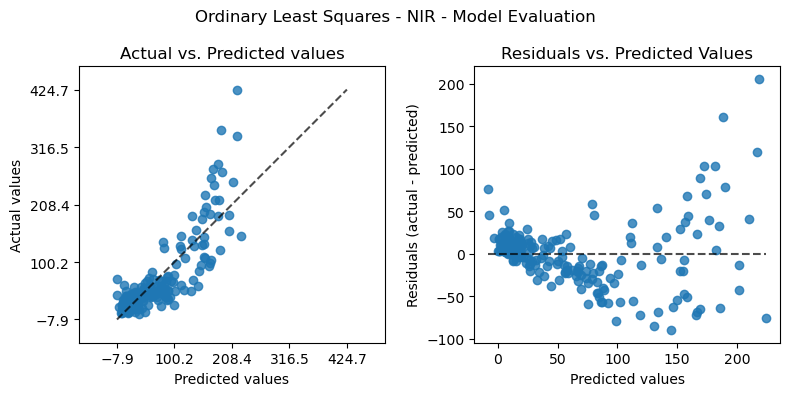

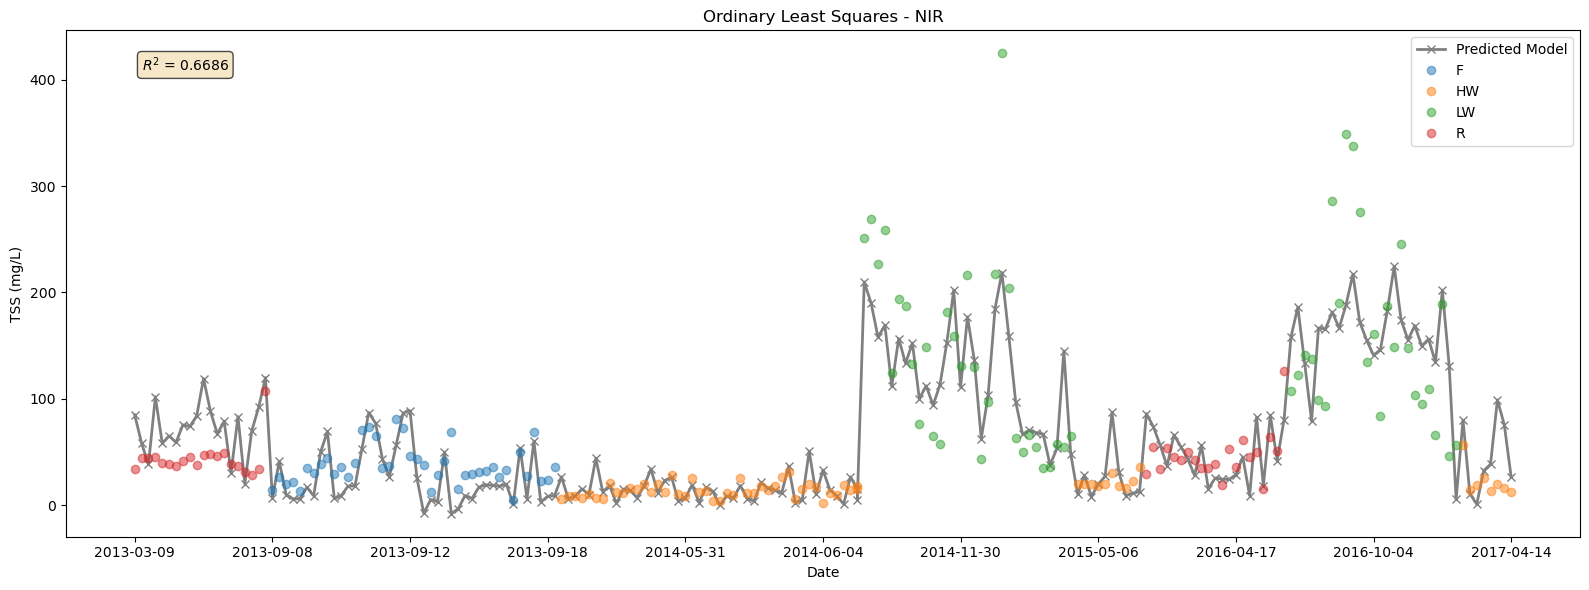


Ordinary Least Squares - RED Results
Training Metrics: {'r2': 0.3348421205868899, 'mae': 37.97414502002991, 'mse': 3371.321146746267, 'mape': 0.9490280170476786, 'exp_var': 0.3348421205868899}
CV Metrics: {'r2': 0.31539759844669657, 'mae': 38.51027562997588, 'mse': 3473.76821326855, 'mape': 0.9783139855635328, 'exp_var': 0.3383960597009329}


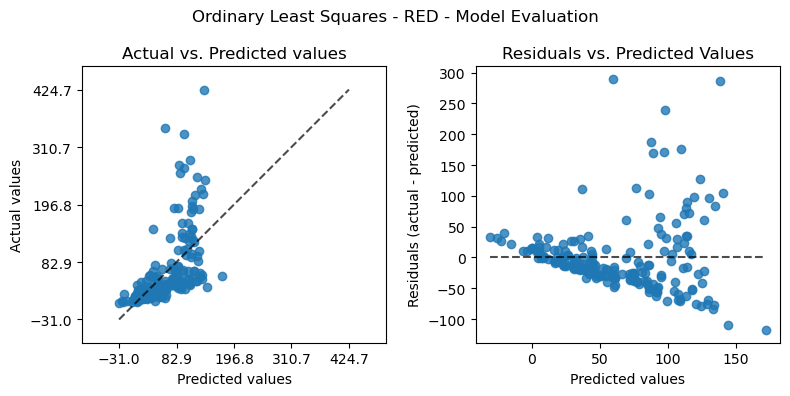

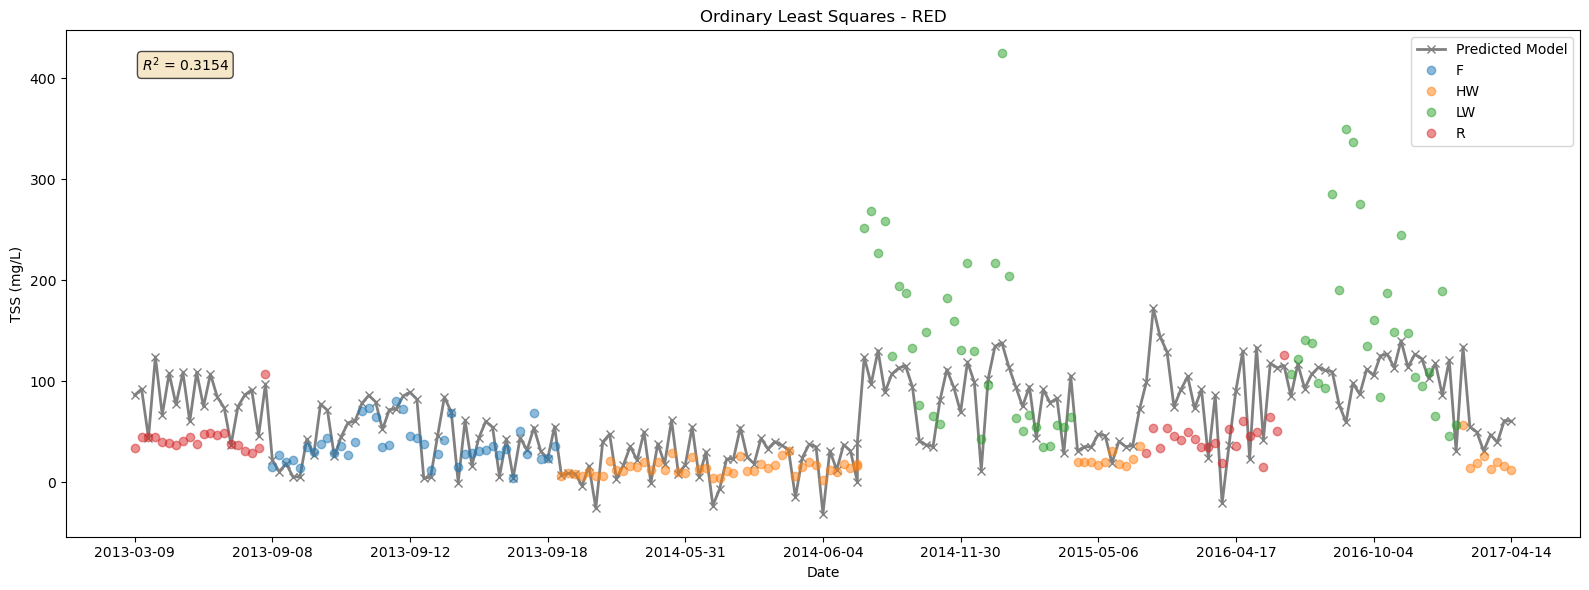


Ordinary Least Squares - GREEN Results
Training Metrics: {'r2': 0.16680740065908584, 'mae': 43.006747992432466, 'mse': 4222.99715061475, 'mape': 1.0242518552979105, 'exp_var': 0.16680740065908584}
CV Metrics: {'r2': 0.1684538929211295, 'mae': 43.88491370169141, 'mse': 4329.854295179924, 'mape': 1.0123357391706, 'exp_var': 0.18053307753562975}


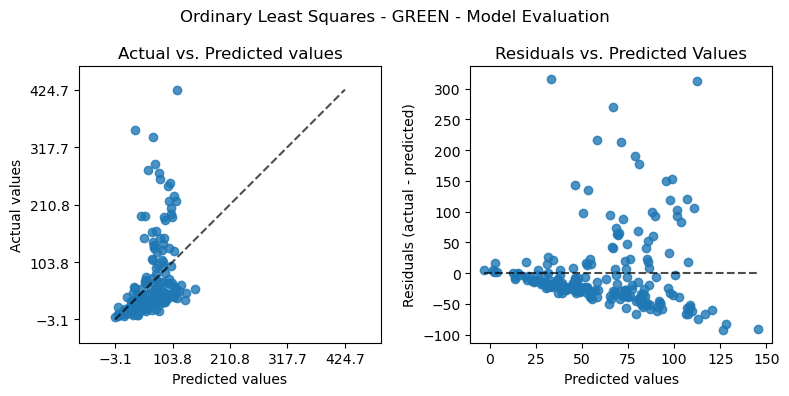

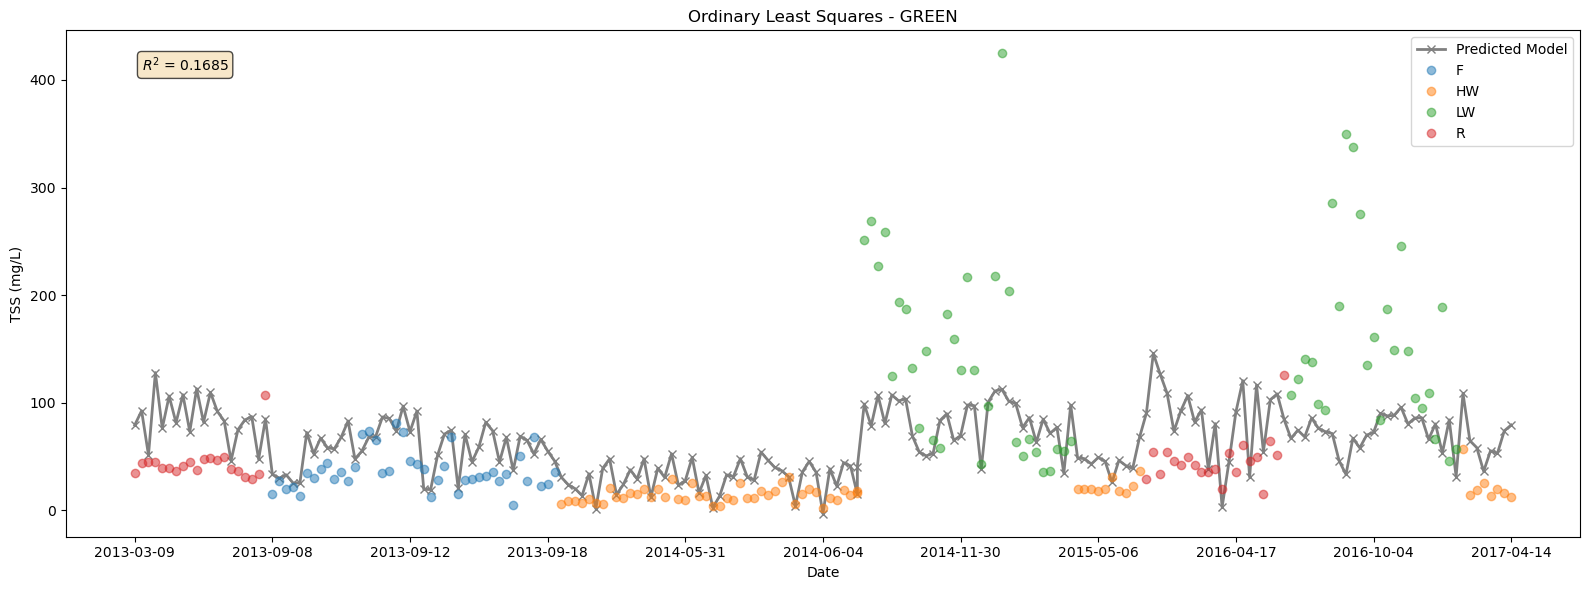


Ordinary Least Squares - BLUE Results
Training Metrics: {'r2': 0.010256838707120242, 'mae': 49.49828387940118, 'mse': 5016.466244763274, 'mape': 1.7564487289056996, 'exp_var': 0.010256838707120464}
CV Metrics: {'r2': 0.052141865654493504, 'mae': 51.175668956635505, 'mse': 5337.666978267825, 'mape': 1.8865831734589278, 'exp_var': 0.02238170178250446}


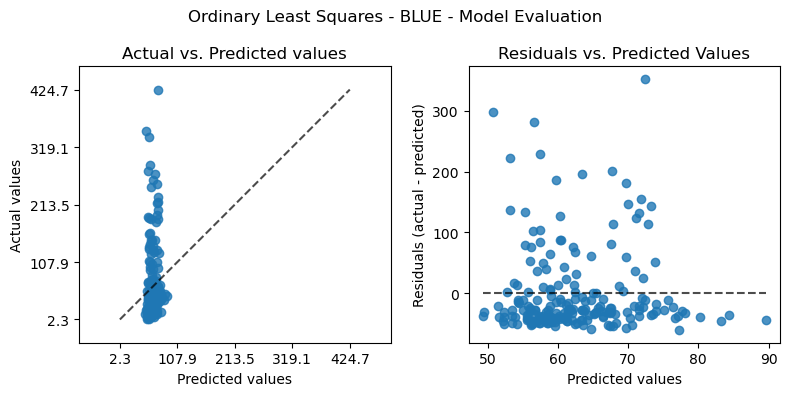

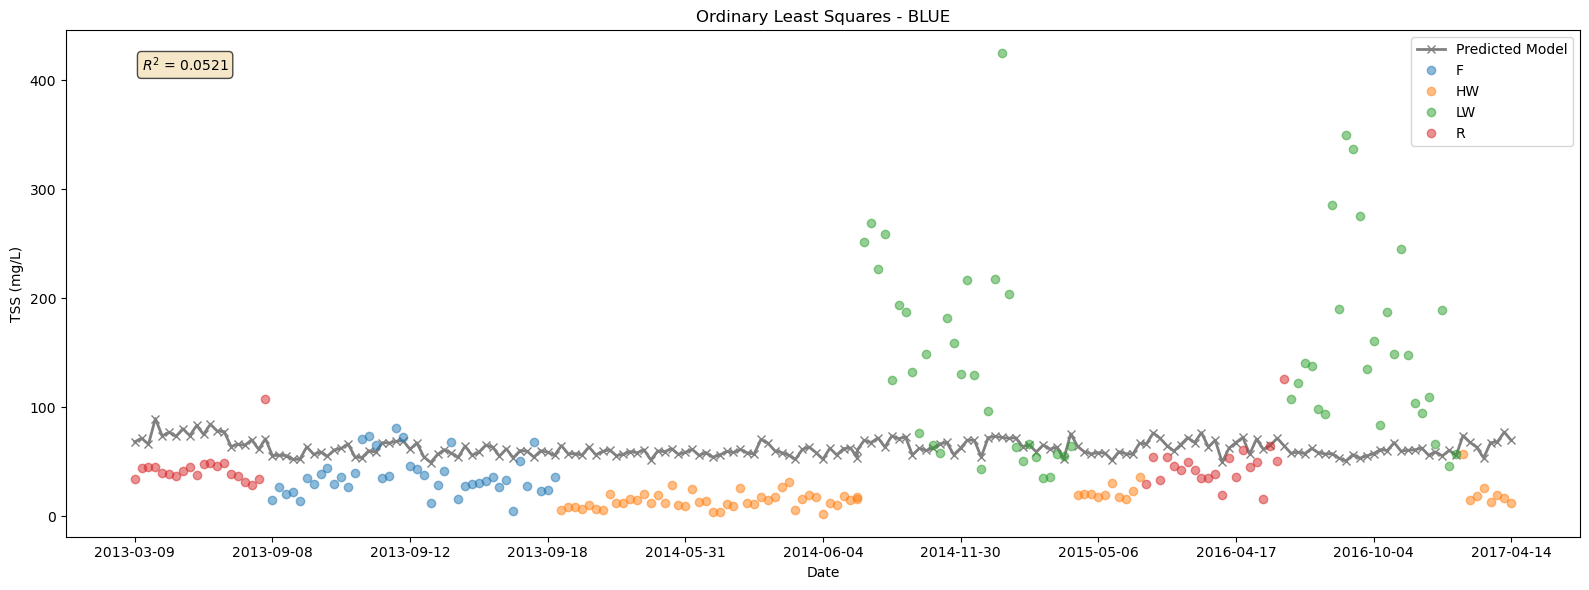


Ordinary Least Squares - NIR/RED ratio Results
Training Metrics: {'r2': 0.00821299816553056, 'mae': 48.912986633174484, 'mse': 5026.825353557892, 'mape': 2.0213428942324976, 'exp_var': 0.008212998165530783}
CV Metrics: {'r2': 2.2277934057454987, 'mae': 57.32427060090727, 'mse': 13299.571873456502, 'mape': 5.366569383467677, 'exp_var': 2.119012113358574}


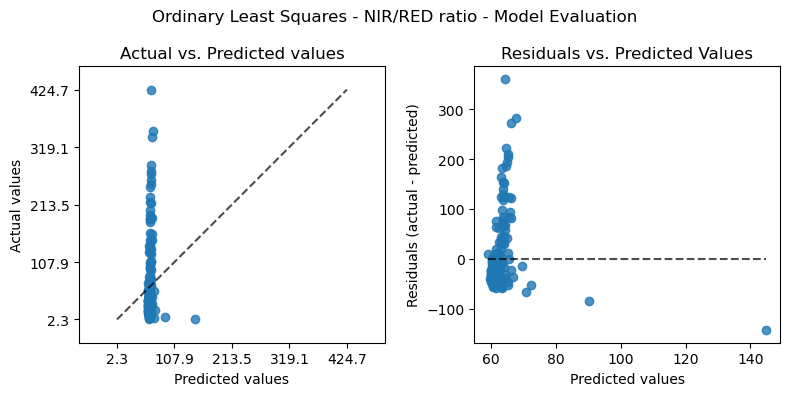

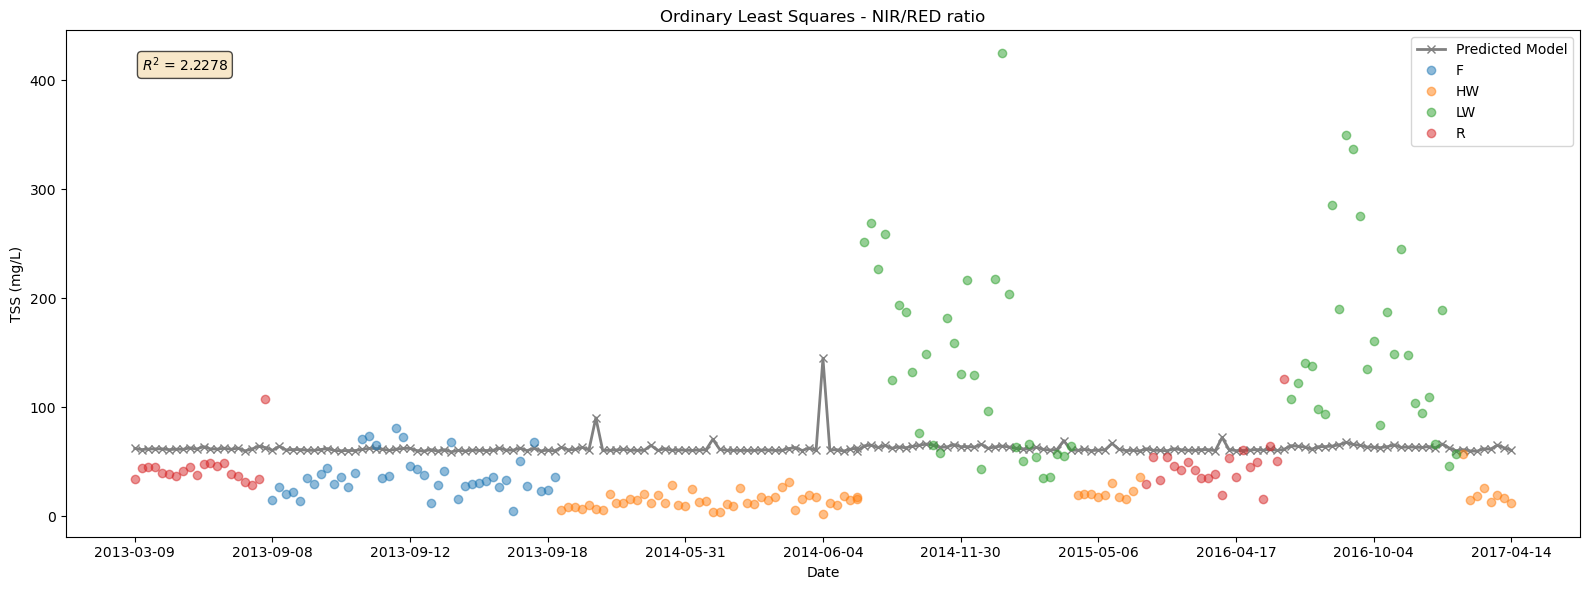


Ordinary Least Squares - RED/NIR ratio Results
Training Metrics: {'r2': 0.13953370638212748, 'mae': 44.745209984164525, 'mse': 4361.232575784683, 'mape': 1.8717215261998383, 'exp_var': 0.1395337063821276}
CV Metrics: {'r2': 0.17894431847967826, 'mae': 46.911007845221846, 'mse': 4692.74811567955, 'mape': 2.1557604220696813, 'exp_var': 0.21784943847414168}


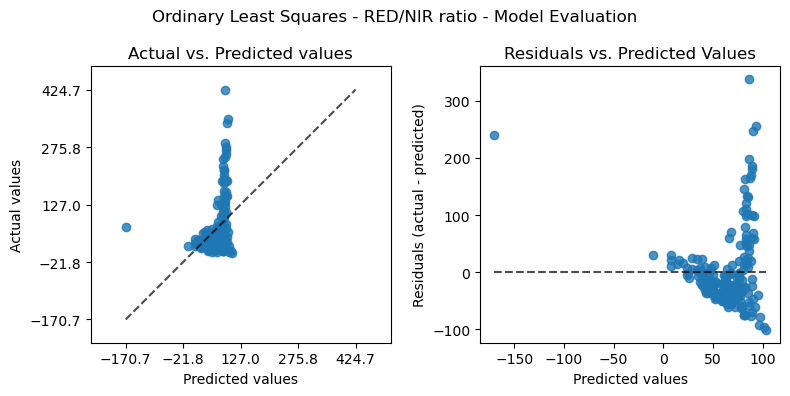

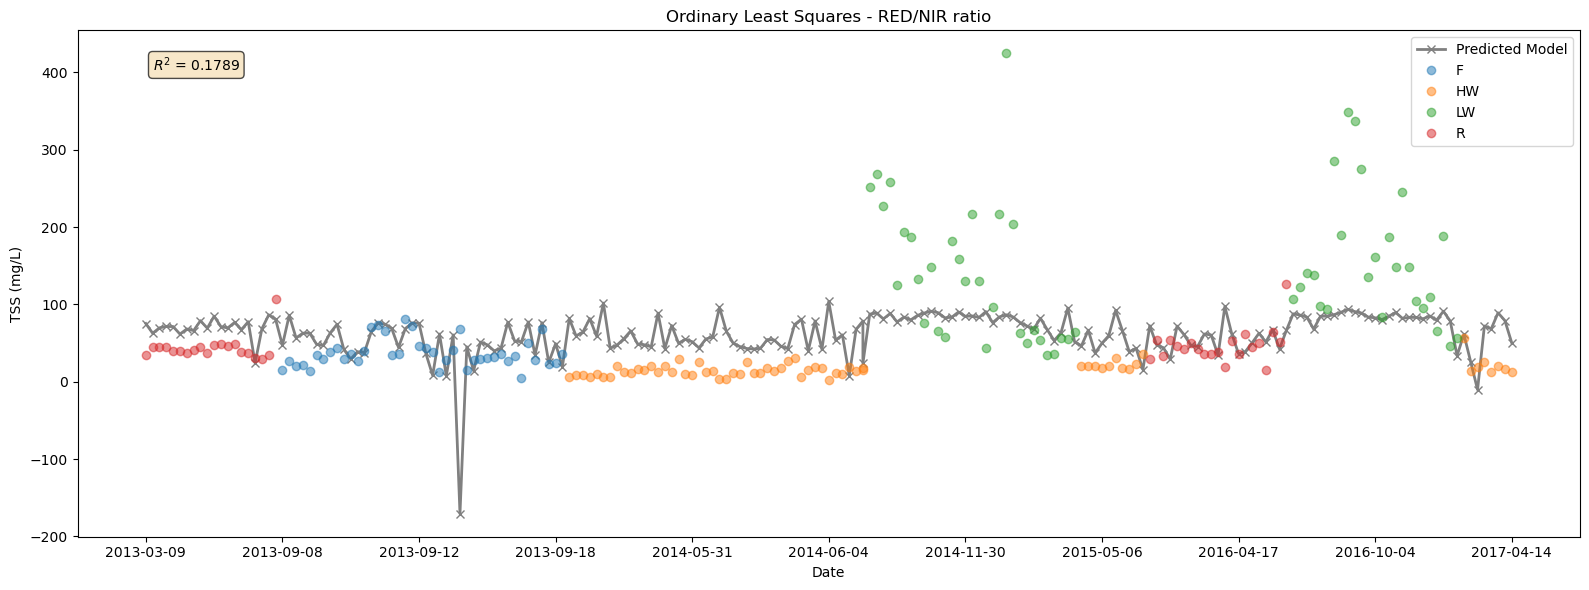


2nd Degree Polynomial - NIR Results
Training Metrics: {'r2': 0.7793424470569921, 'mae': 21.526140512395138, 'mse': 1118.3923357901433, 'mape': 0.5991826834492824, 'exp_var': 0.7793424470569921}
CV Metrics: {'r2': 0.7110267182662355, 'mae': 21.765620154767483, 'mse': 1183.0973368575544, 'mape': 0.6651932603160915, 'exp_var': 0.7186491588847354}


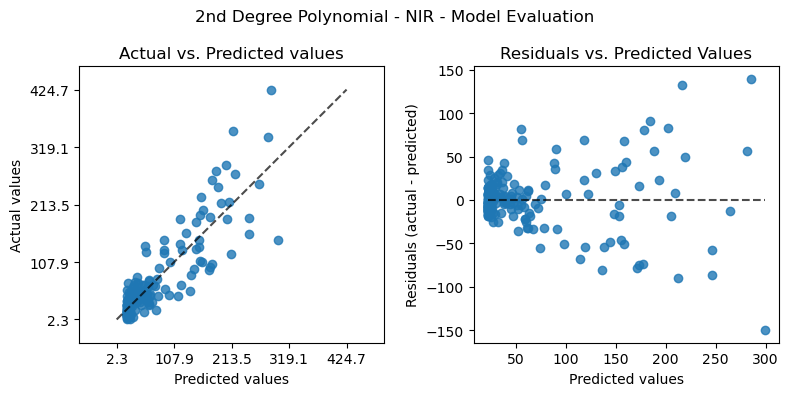

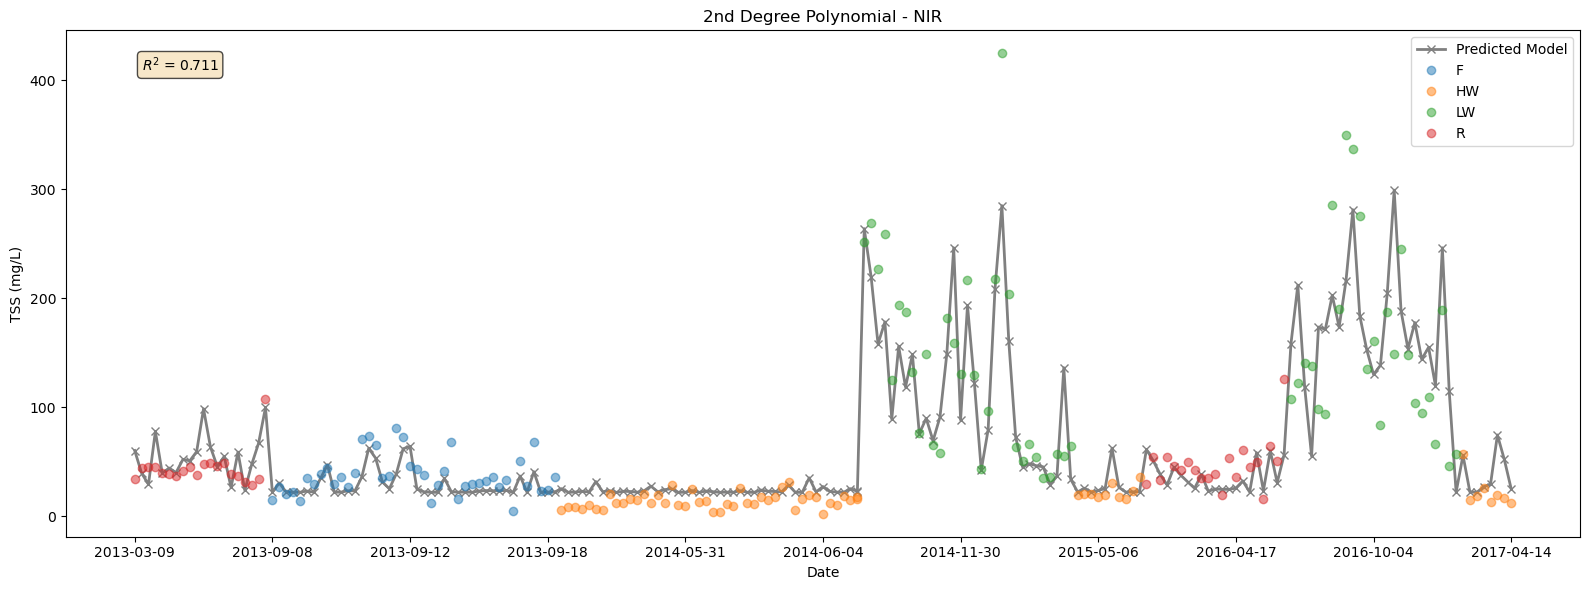


2nd Degree Polynomial - RED Results
Training Metrics: {'r2': 0.3408618073397923, 'mae': 36.27544420204008, 'mse': 3340.810650103342, 'mape': 0.785372910065961, 'exp_var': 0.3408618073397923}
CV Metrics: {'r2': 0.3162482342649584, 'mae': 36.84171745214857, 'mse': 3494.5990954198255, 'mape': 0.7614182561420368, 'exp_var': 0.33227409731983526}


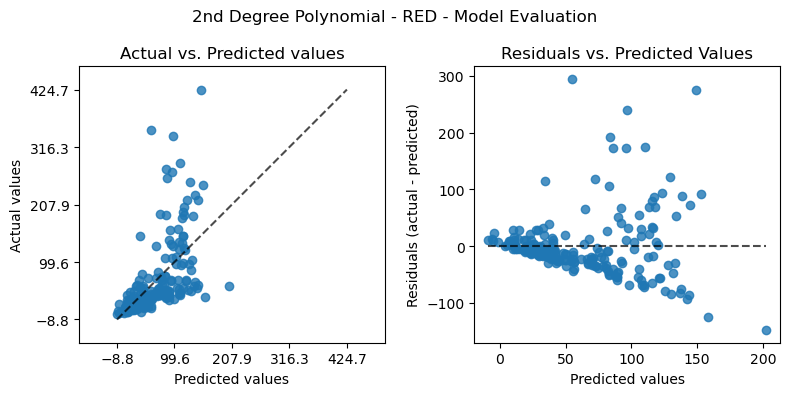

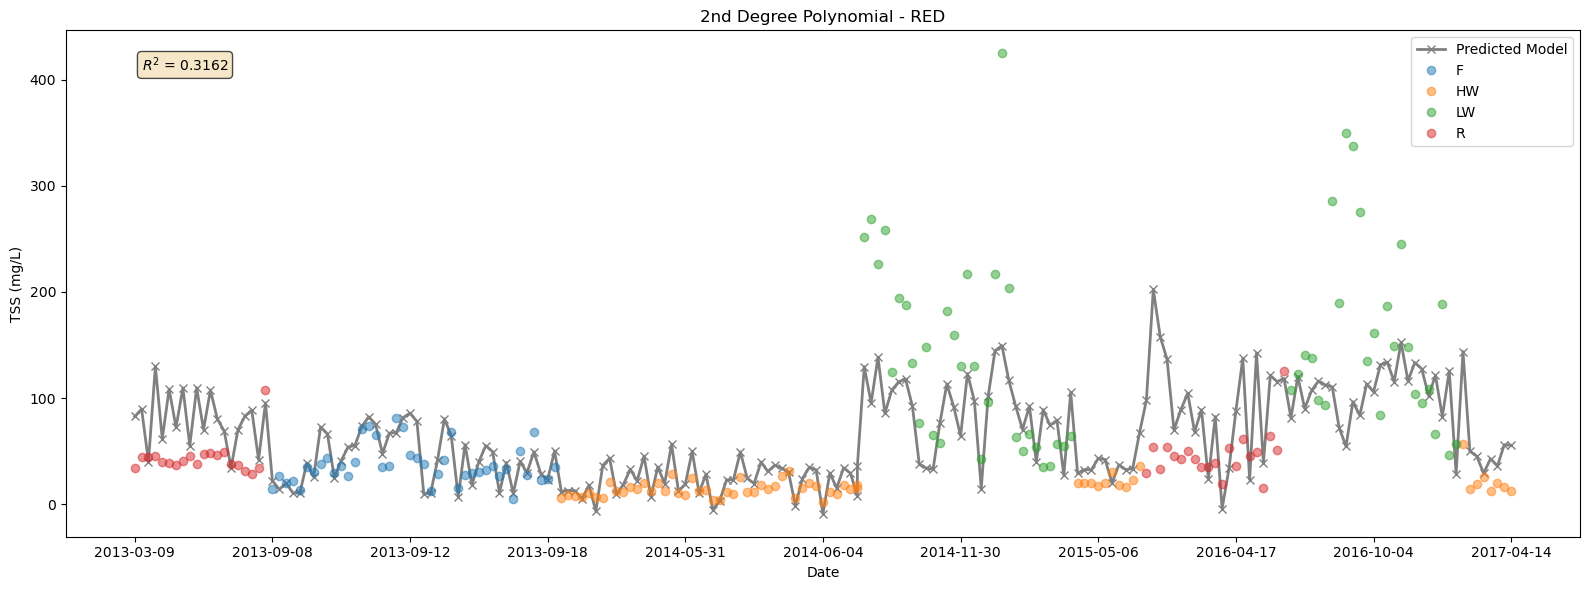


2nd Degree Polynomial - GREEN Results
Training Metrics: {'r2': 0.1731573972665943, 'mae': 43.49417232191861, 'mse': 4190.812494148605, 'mape': 1.1194450130191371, 'exp_var': 0.1731573972665944}
CV Metrics: {'r2': 0.1659723043003032, 'mae': 44.475499546545805, 'mse': 4340.1771429977725, 'mape': 1.1218905411582665, 'exp_var': 0.18519407764777712}


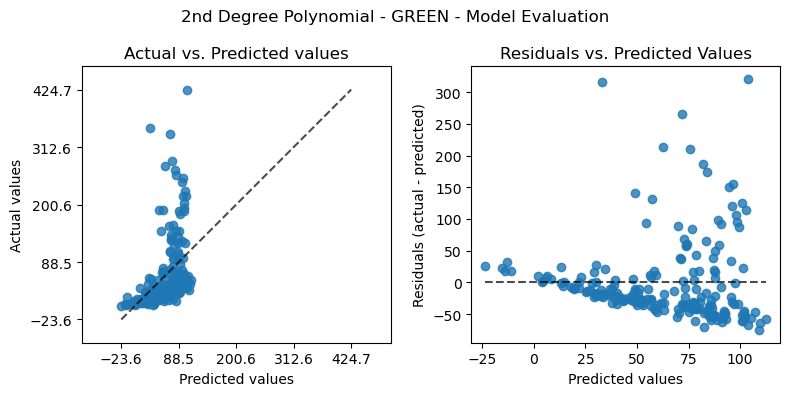

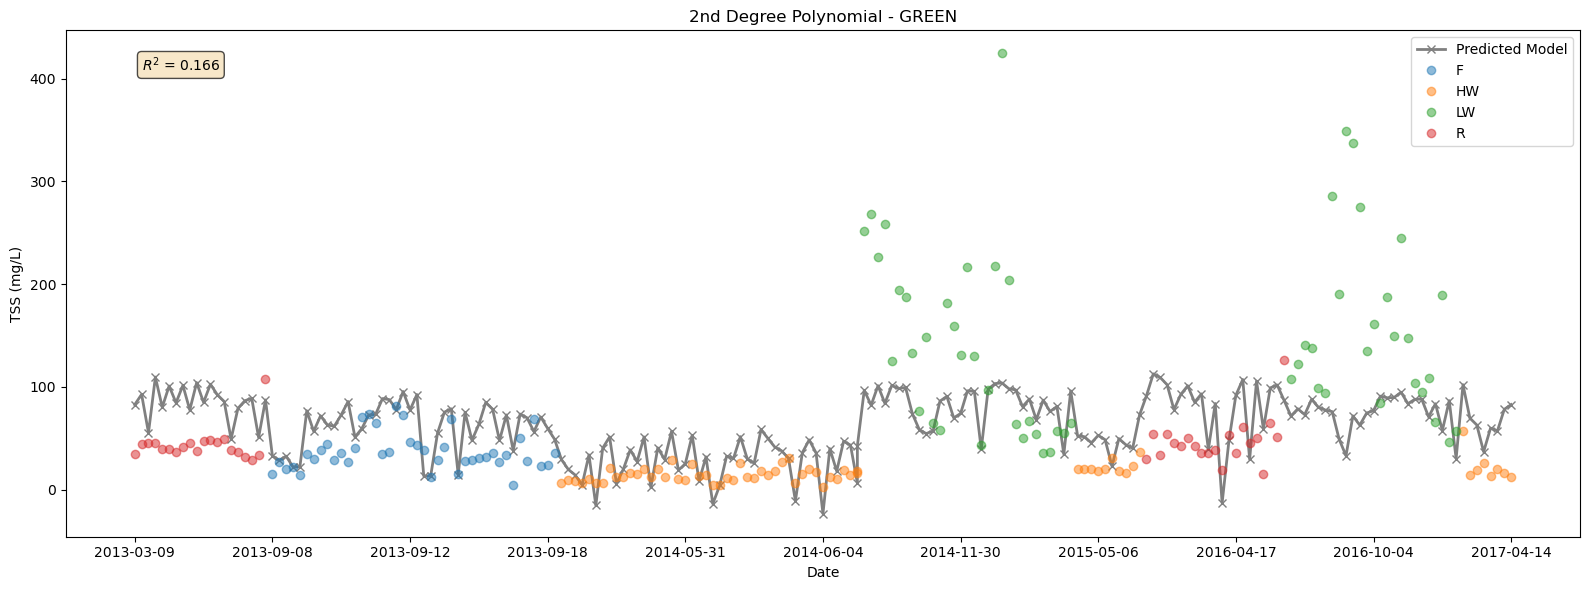


2nd Degree Polynomial - BLUE Results
Training Metrics: {'r2': 0.010978824469198178, 'mae': 49.38384263797979, 'mse': 5012.8068941900065, 'mape': 1.7421360743859473, 'exp_var': 0.01097882446919829}
CV Metrics: {'r2': 0.054166228876463406, 'mae': 51.23602681133566, 'mse': 5364.728337456592, 'mape': 1.878162541445161, 'exp_var': 0.022645888956746834}


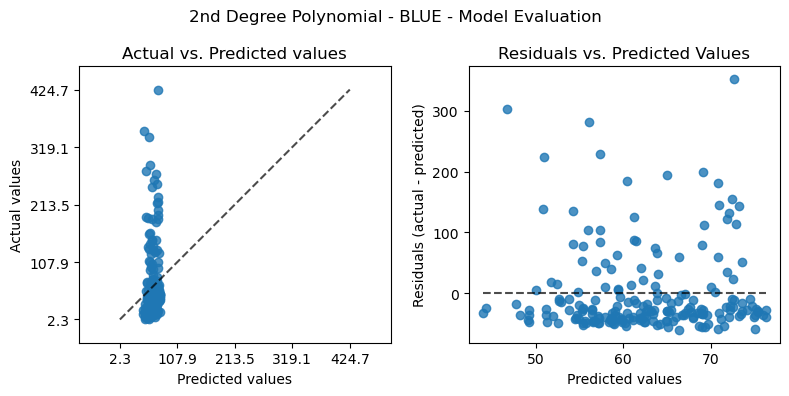

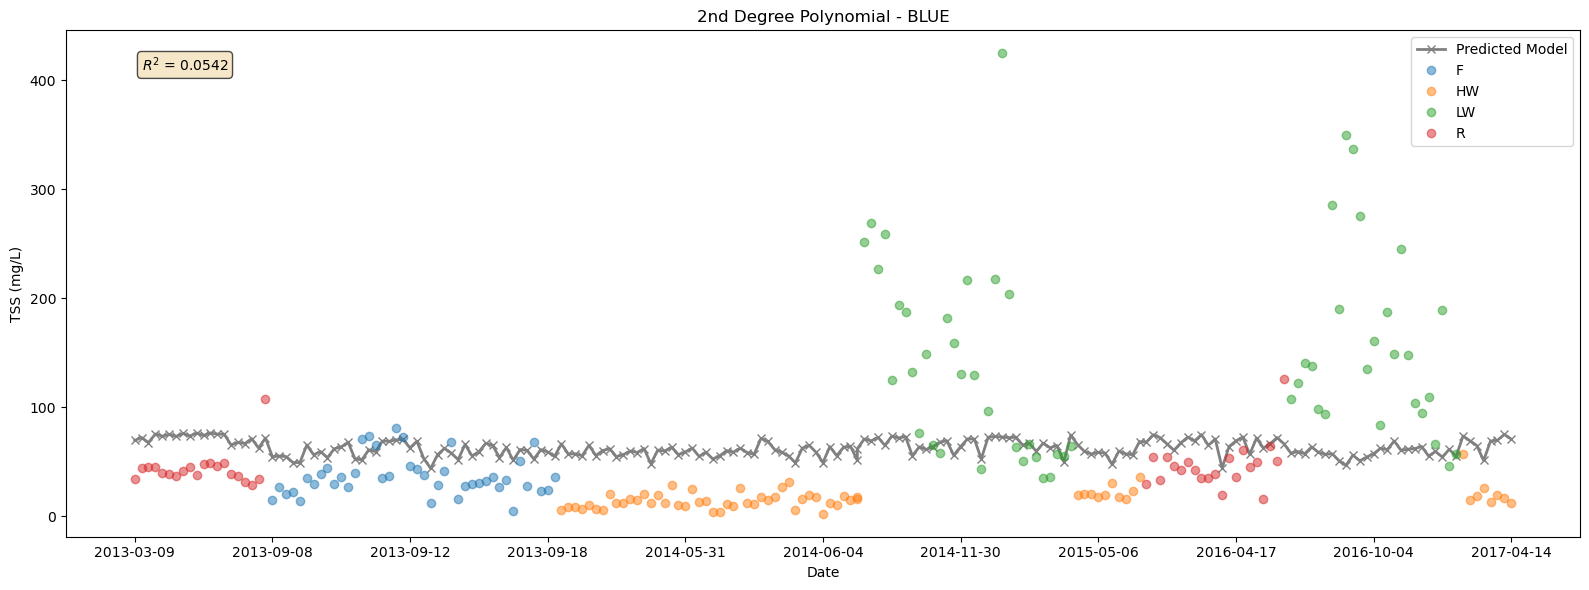


2nd Degree Polynomial - NIR/RED ratio Results
Training Metrics: {'r2': 0.1776738141909714, 'mae': 41.05903632903344, 'mse': 4167.9212492939105, 'mape': 1.7623634586988681, 'exp_var': 0.1776738141909714}
CV Metrics: {'r2': 197.7711531019791, 'mae': 113.75751760362138, 'mse': 812826.9353049233, 'mape': 31.6893520124082, 'exp_var': 190.62456850576817}


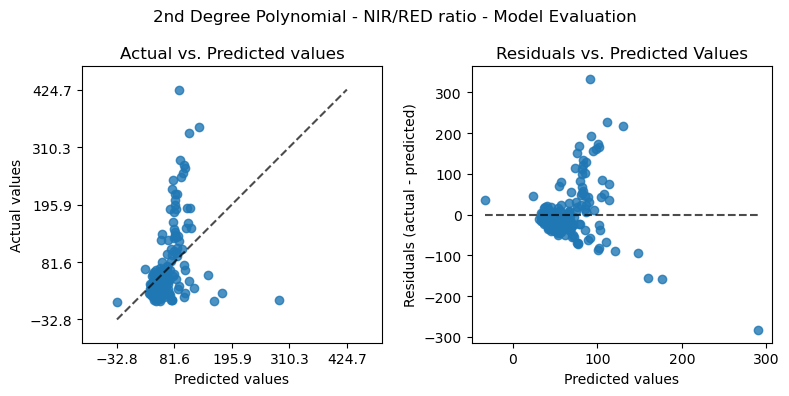

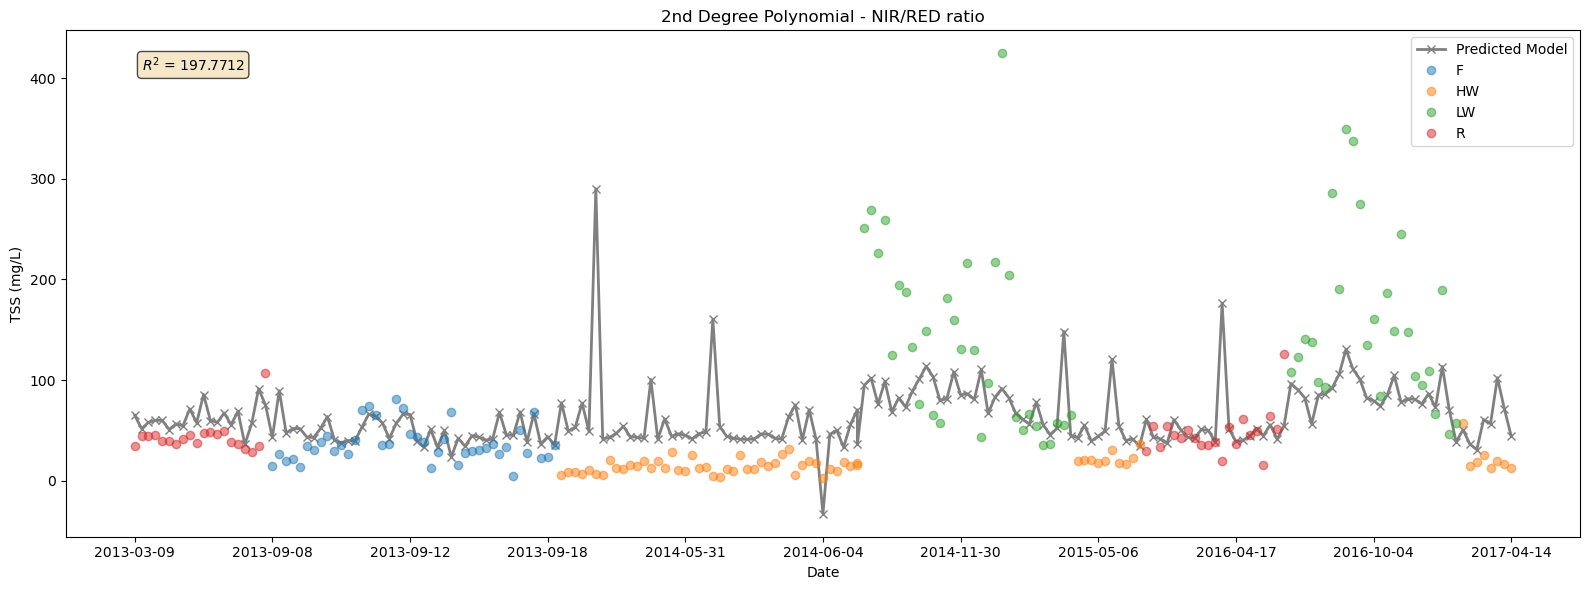


2nd Degree Polynomial - RED/NIR ratio Results
Training Metrics: {'r2': 0.2584927557683495, 'mae': 41.93396330391389, 'mse': 3758.294279170859, 'mape': 1.9061713148869837, 'exp_var': 0.2584927557683494}
CV Metrics: {'r2': 1.0856175450019911, 'mae': 47.18423103686217, 'mse': 7926.511646007452, 'mape': 2.348002195627008, 'exp_var': 1.0747399141619616}


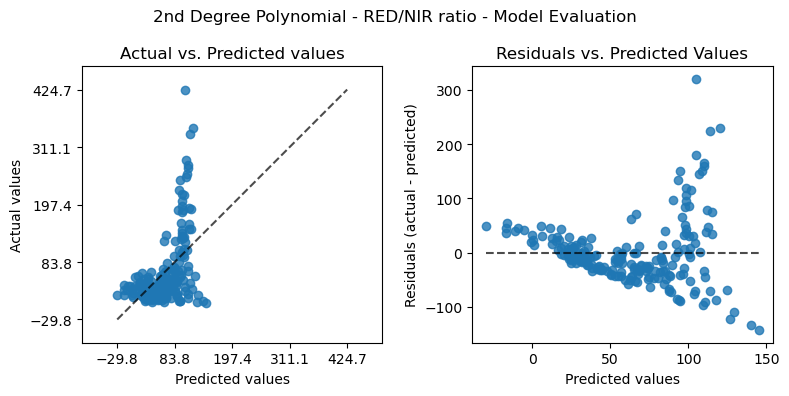

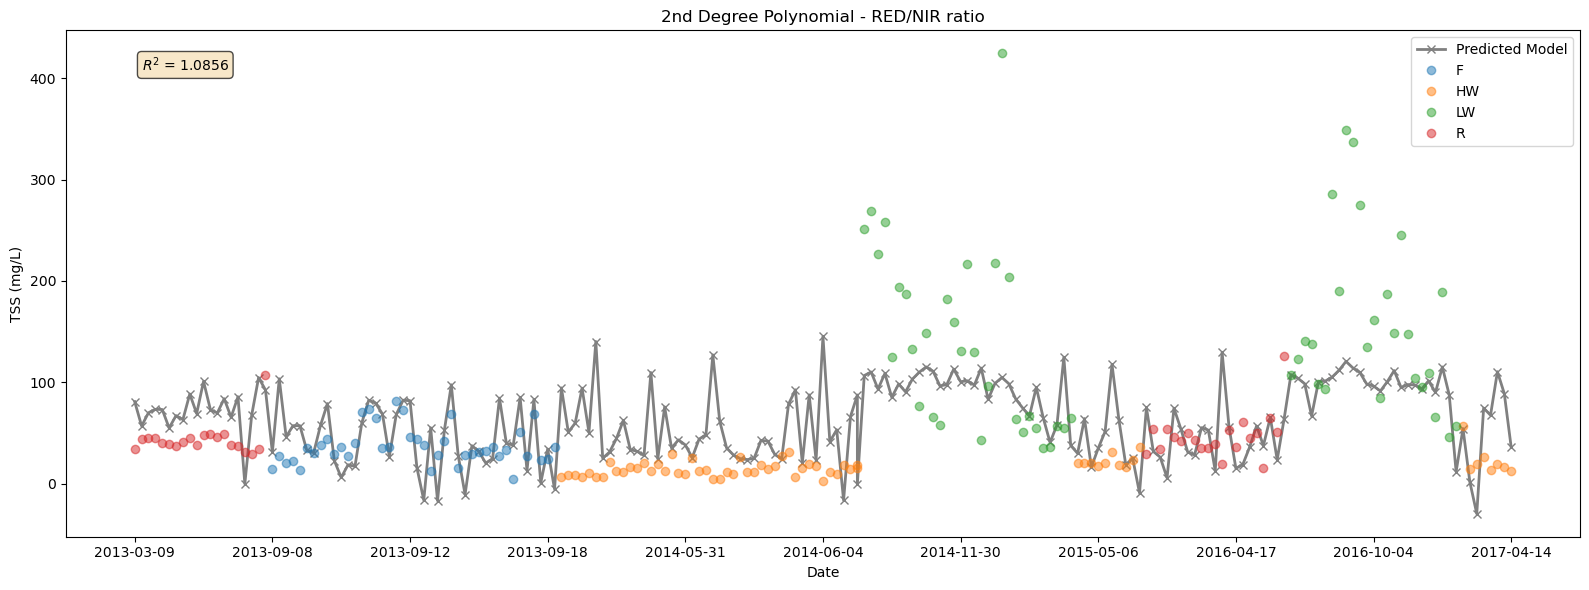


3rd Degree Polynomial - NIR Results
Training Metrics: {'r2': 0.7794841504510401, 'mae': 21.459989178329582, 'mse': 1117.674118861943, 'mape': 0.5952588976165494, 'exp_var': 0.7794841504510401}
CV Metrics: {'r2': 0.7217915372442107, 'mae': 21.916410707579008, 'mse': 1239.8580588433613, 'mape': 0.6671184041777416, 'exp_var': 0.7222845394480448}


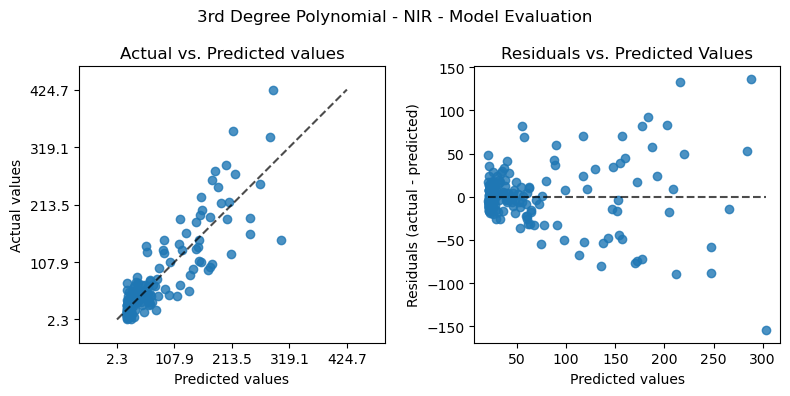

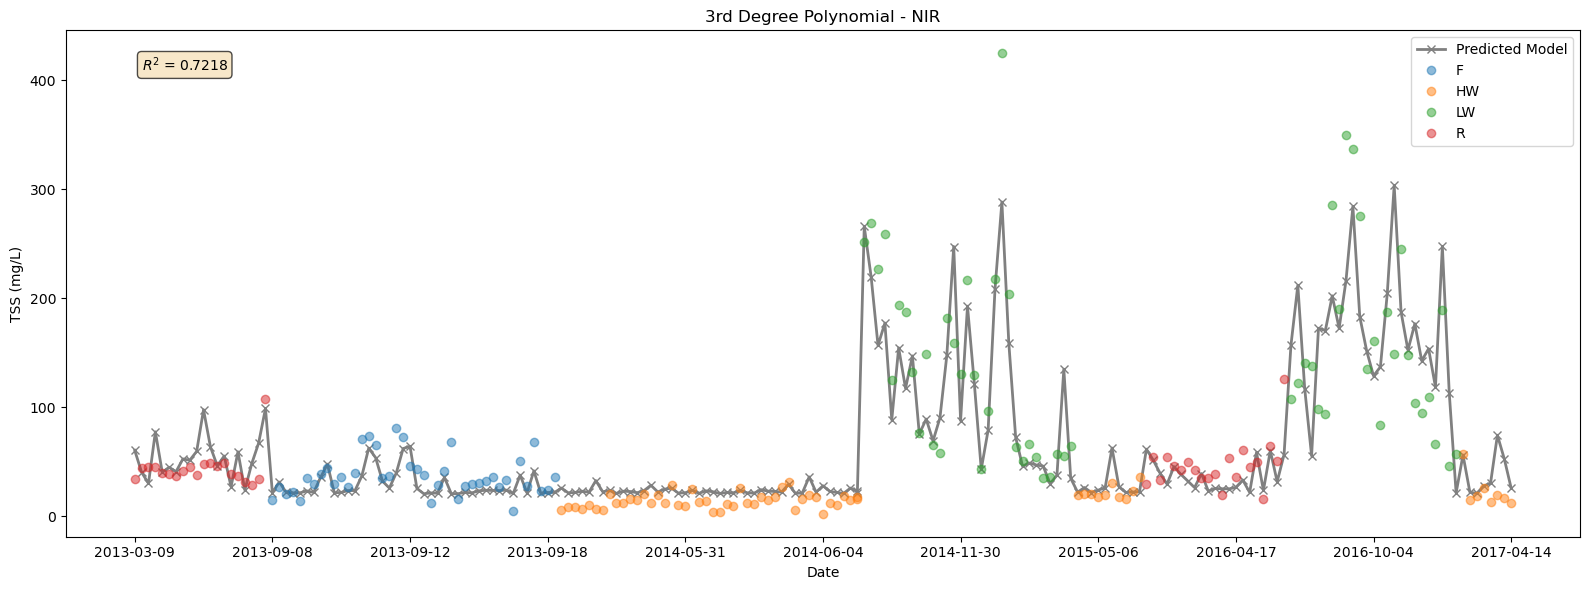


3rd Degree Polynomial - RED Results
Training Metrics: {'r2': 0.3556382768881797, 'mae': 35.63814980601803, 'mse': 3265.916815414524, 'mape': 0.7812067302315266, 'exp_var': 0.3556382768881797}
CV Metrics: {'r2': 0.32126835233582796, 'mae': 36.612476240358156, 'mse': 3449.650895990583, 'mape': 0.8534363162893591, 'exp_var': 0.33583507172270743}


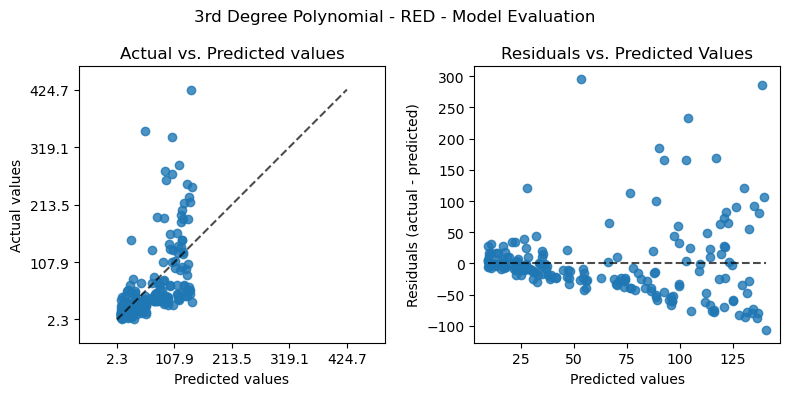

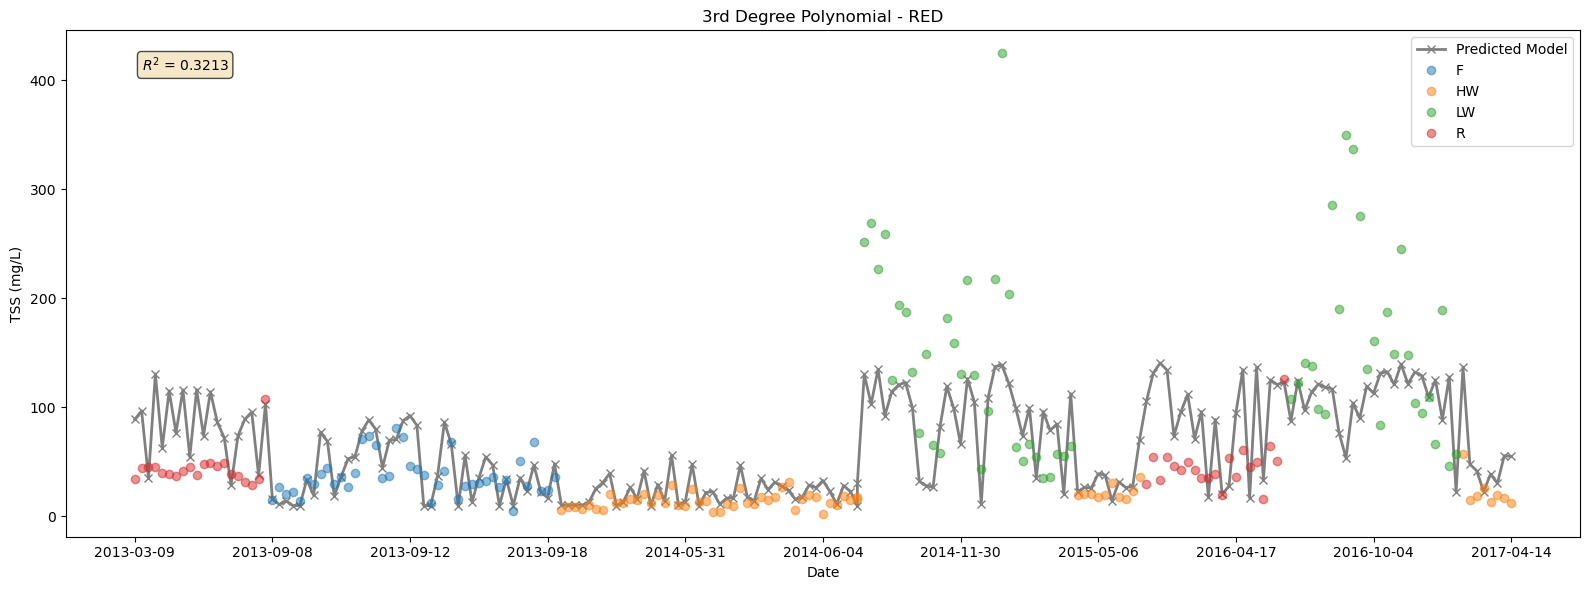


3rd Degree Polynomial - GREEN Results
Training Metrics: {'r2': 0.18661417151995452, 'mae': 41.7925639146579, 'mse': 4122.607472436508, 'mape': 0.9612172155011143, 'exp_var': 0.18661417151995452}
CV Metrics: {'r2': 0.18908068779052128, 'mae': 42.962868760773915, 'mse': 4276.026863755604, 'mape': 0.985225884751656, 'exp_var': 0.20286880132775548}


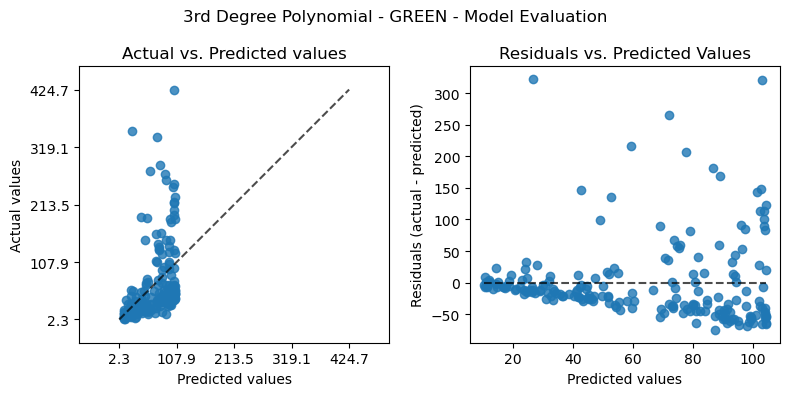

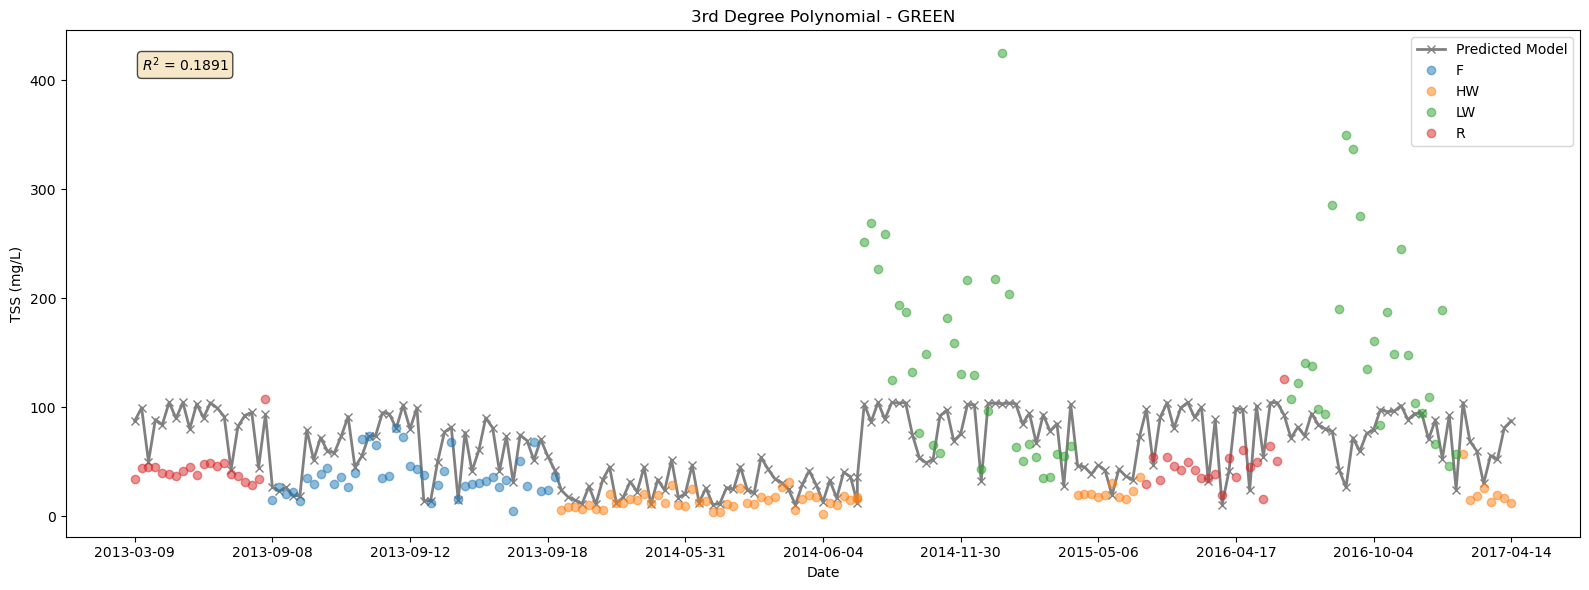


3rd Degree Polynomial - BLUE Results
Training Metrics: {'r2': 0.02950402381335837, 'mae': 49.53335935788185, 'mse': 4918.912800427241, 'mape': 1.7689928970891216, 'exp_var': 0.02950402381335826}
CV Metrics: {'r2': 0.09895760402661524, 'mae': 51.677237053757686, 'mse': 5381.300684681682, 'mape': 1.9472811126271636, 'exp_var': 0.07084237474223948}


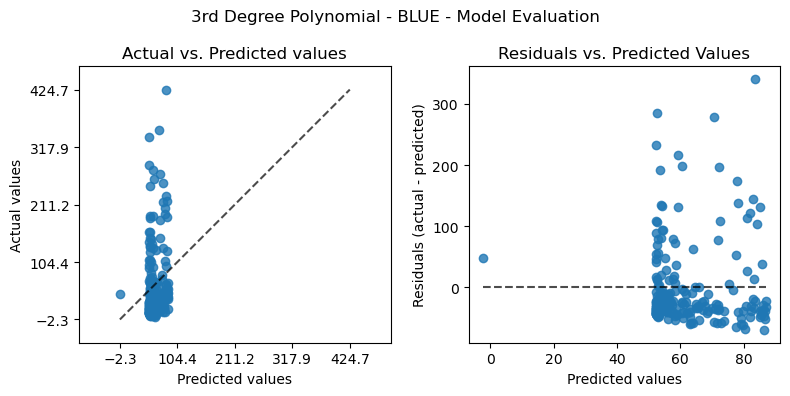

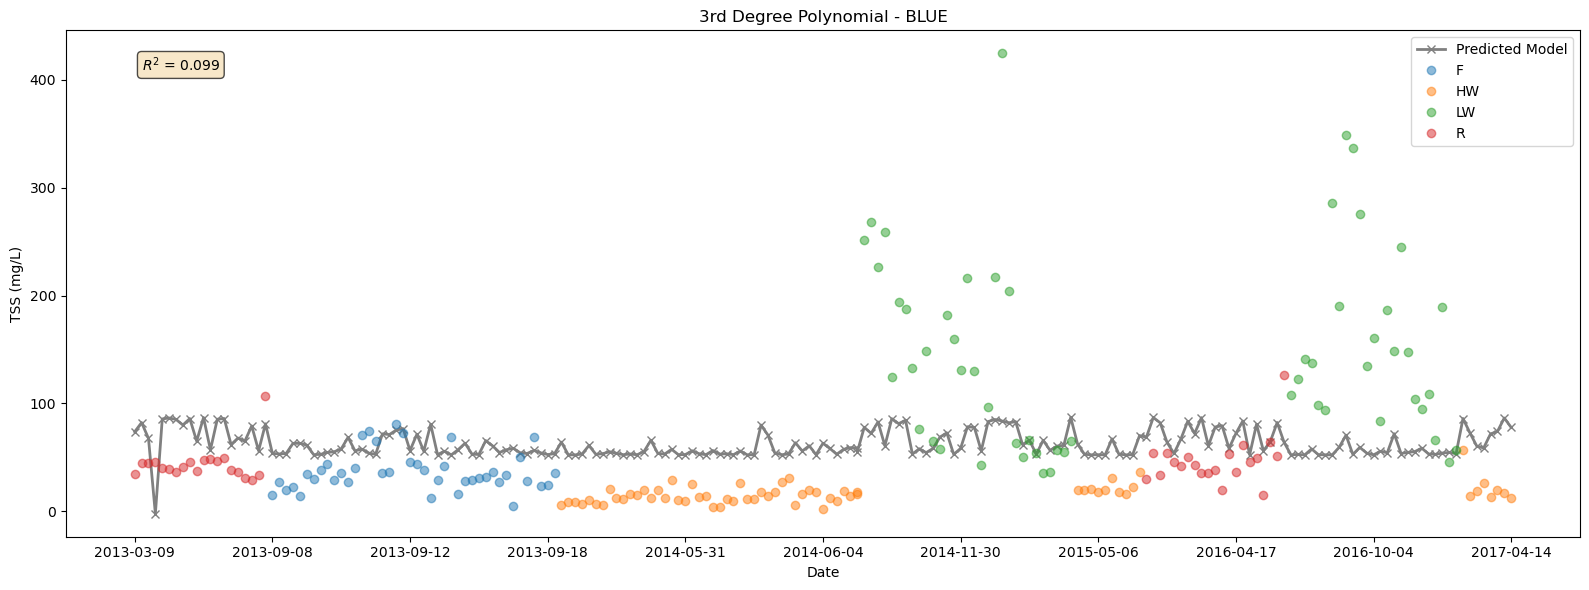


3rd Degree Polynomial - NIR/RED ratio Results
Training Metrics: {'r2': 0.3419021440770701, 'mae': 37.13517492258442, 'mse': 3335.5377527196174, 'mape': 1.4656088457343739, 'exp_var': 0.34190214407707}
CV Metrics: {'r2': 39327.20382937242, 'mae': 782.2611349654626, 'mse': 173632824.77572602, 'mape': 314.8278634822833, 'exp_var': 37972.2690635515}


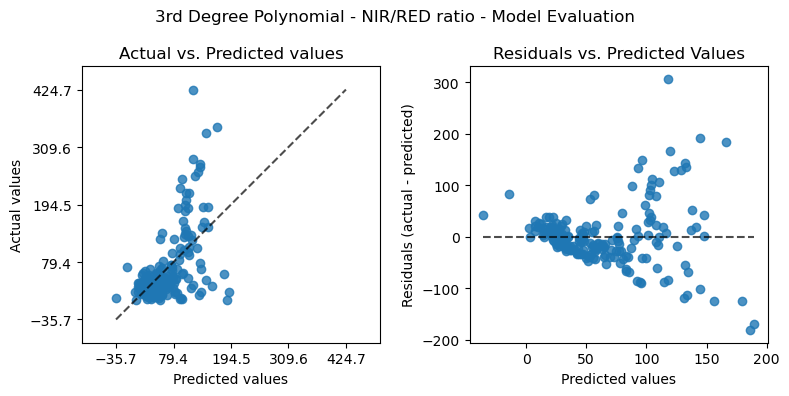

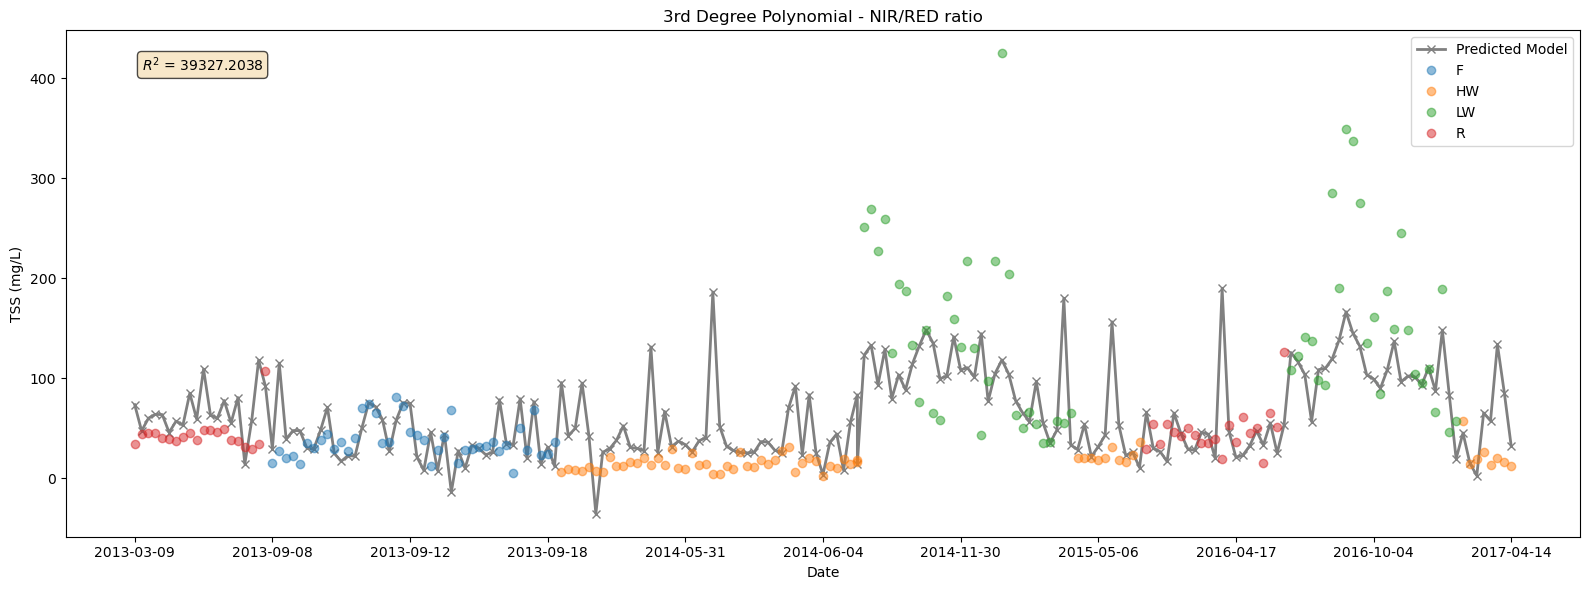


3rd Degree Polynomial - RED/NIR ratio Results
Training Metrics: {'r2': 0.2915755207790214, 'mae': 37.871003256232335, 'mse': 3590.6158546564807, 'mape': 1.8409020442854207, 'exp_var': 0.2915755207790214}
CV Metrics: {'r2': 4.690546747970033, 'mae': 46.59476694652447, 'mse': 23584.440427460388, 'mape': 2.4557299144197837, 'exp_var': 4.5608883921967625}


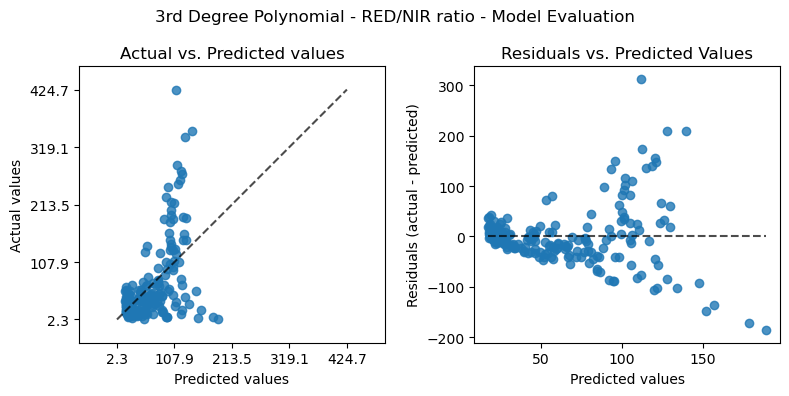

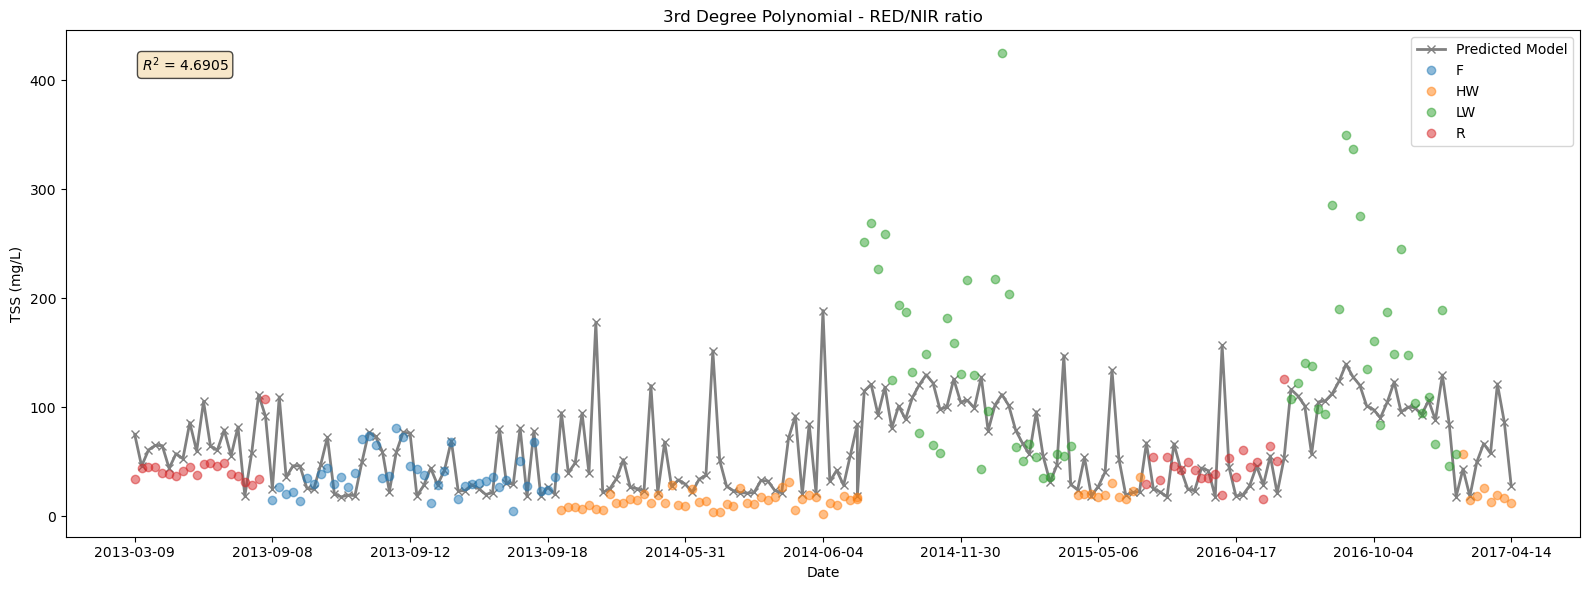


Spline Transformation - NIR Results
Training Metrics: {'r2': 0.7872778522303843, 'mae': 21.183445021229748, 'mse': 1078.1721112433606, 'mape': 0.5864789491281641, 'exp_var': 0.7872778522303843}
CV Metrics: {'r2': 0.6991995477694257, 'mae': 22.336209703623155, 'mse': 1306.5527472734188, 'mape': 0.6808653821735088, 'exp_var': 0.7015452680477969}


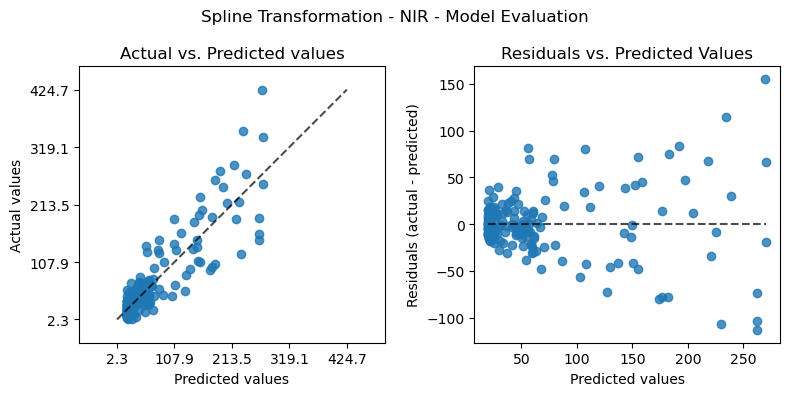

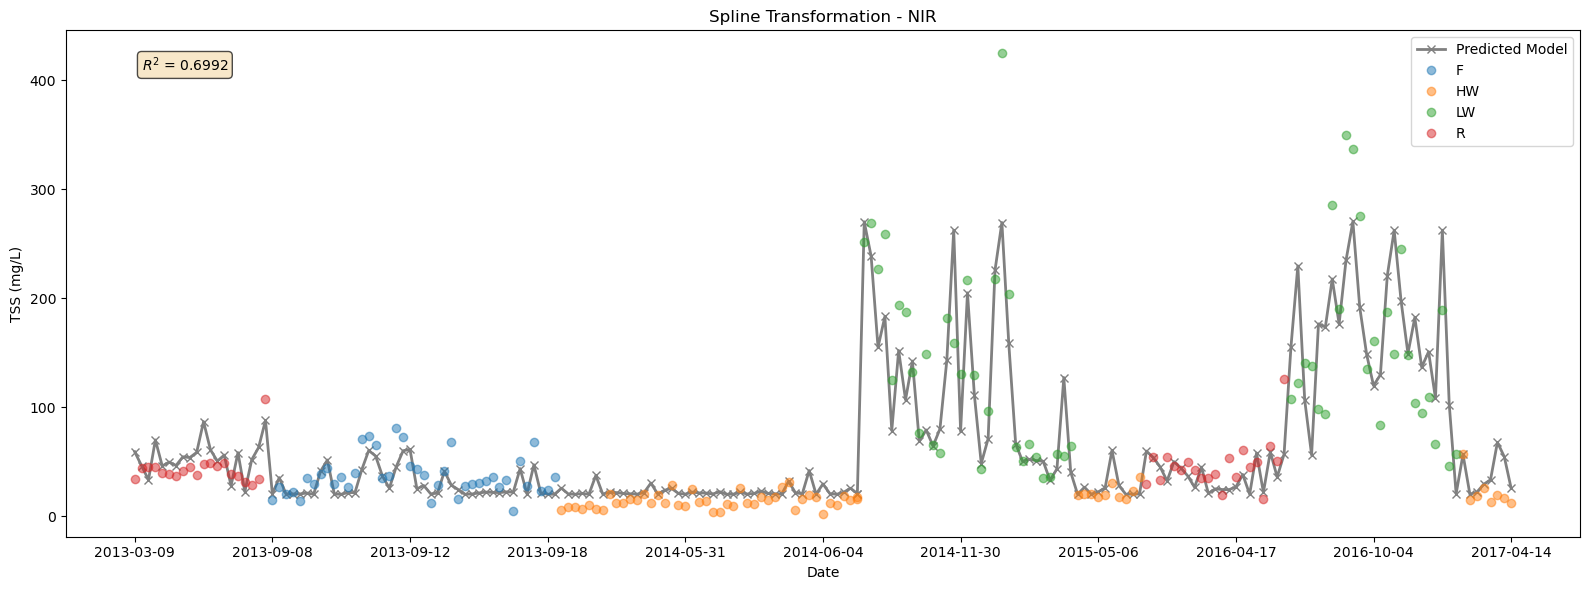


Spline Transformation - RED Results
Training Metrics: {'r2': 0.368397643177089, 'mae': 34.29729219230459, 'mse': 3201.246572874759, 'mape': 0.6954456642209851, 'exp_var': 0.3683976431770891}
CV Metrics: {'r2': 0.3285912115474156, 'mae': 35.612999875948034, 'mse': 3464.7022999216606, 'mape': 0.7070365821740364, 'exp_var': 0.33496691595177913}


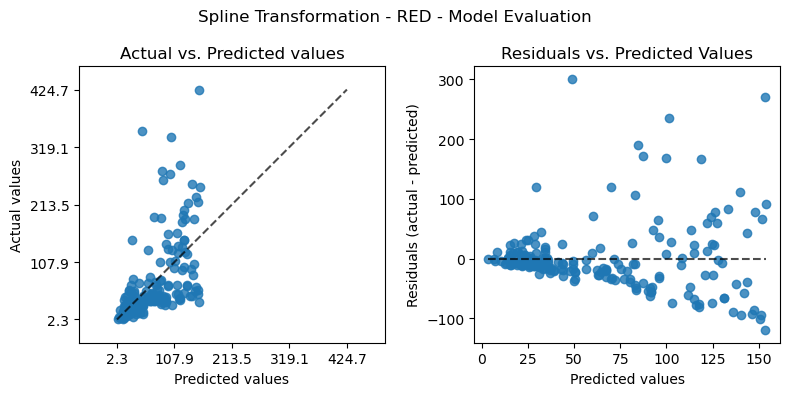

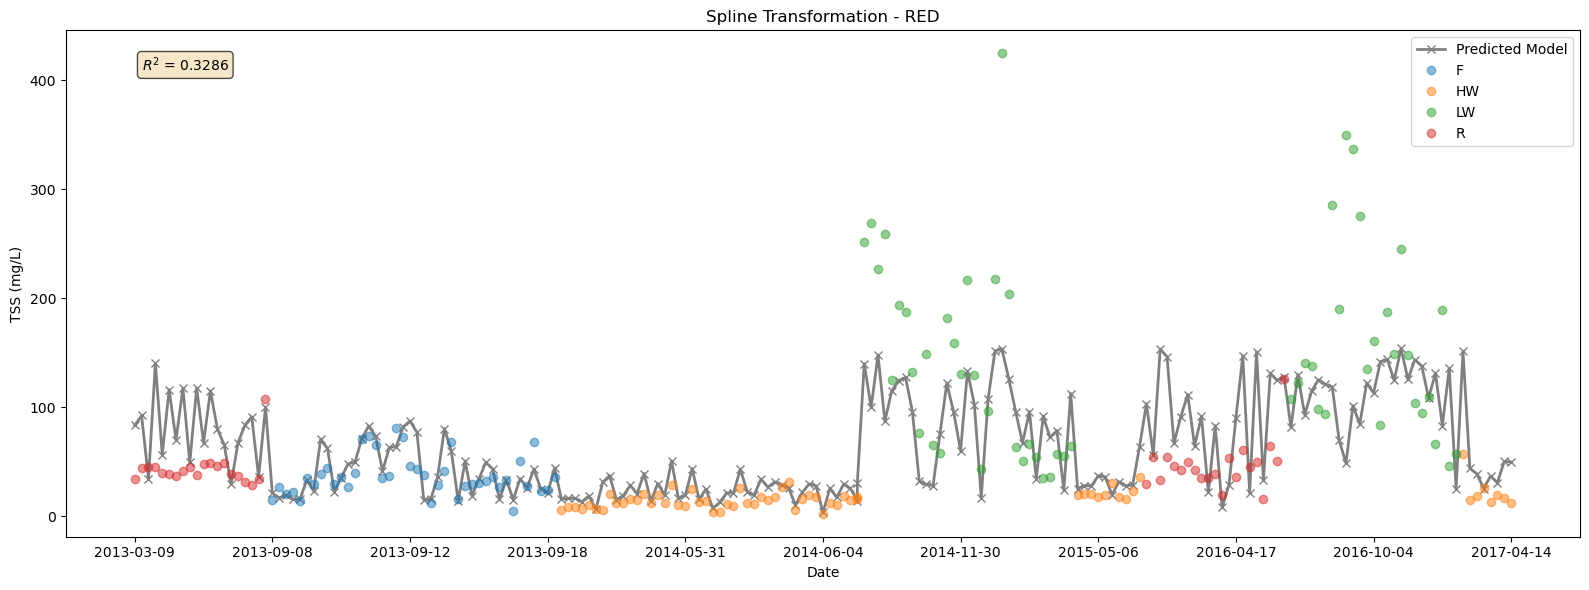


Spline Transformation - GREEN Results
Training Metrics: {'r2': 0.18803205847721882, 'mae': 41.805590893959554, 'mse': 4115.420979679421, 'mape': 0.9561504949583771, 'exp_var': 0.18803205847721904}
CV Metrics: {'r2': 0.18387597474380168, 'mae': 43.62473912377787, 'mse': 4363.217154441765, 'mape': 0.9668554343217874, 'exp_var': 0.1803793723434711}


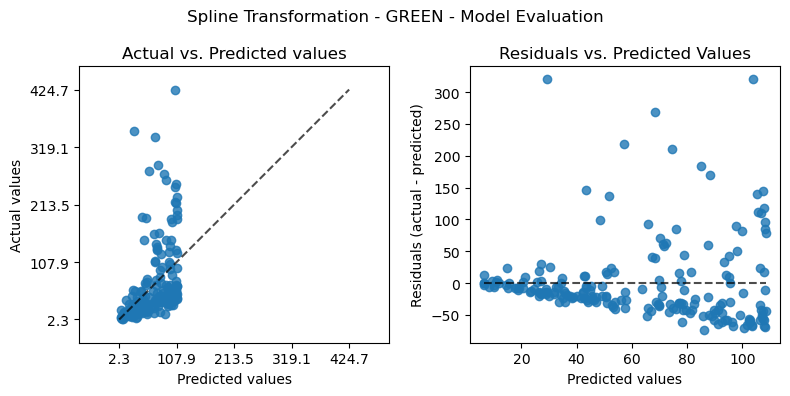

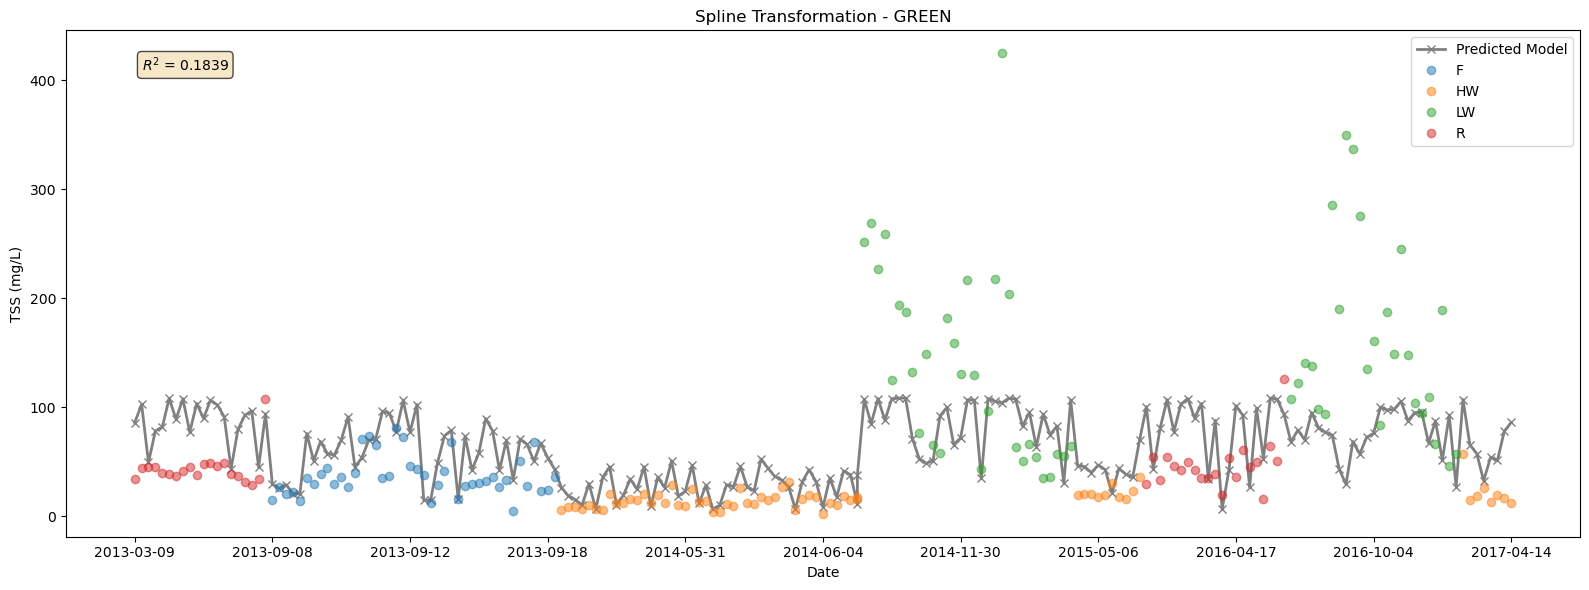


Spline Transformation - BLUE Results
Training Metrics: {'r2': 0.04727525013295808, 'mae': 48.83278979694716, 'mse': 4828.840183159678, 'mape': 1.7813751513798215, 'exp_var': 0.04727525013295819}
CV Metrics: {'r2': 0.113076035151663, 'mae': 51.722100347791994, 'mse': 5386.3825553308825, 'mape': 2.019154274472085, 'exp_var': 0.08779550499120109}


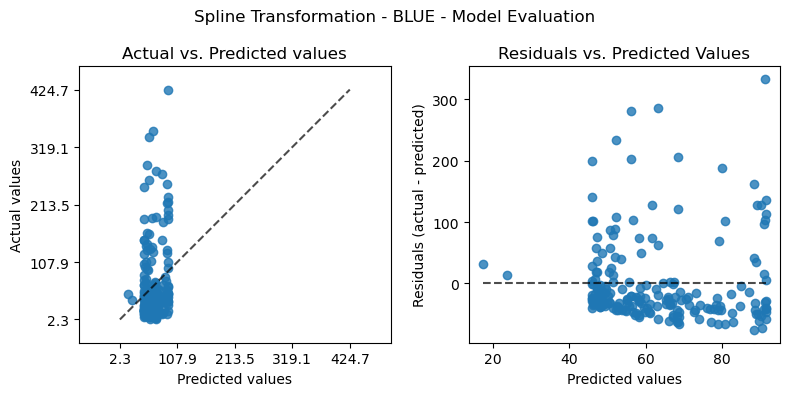

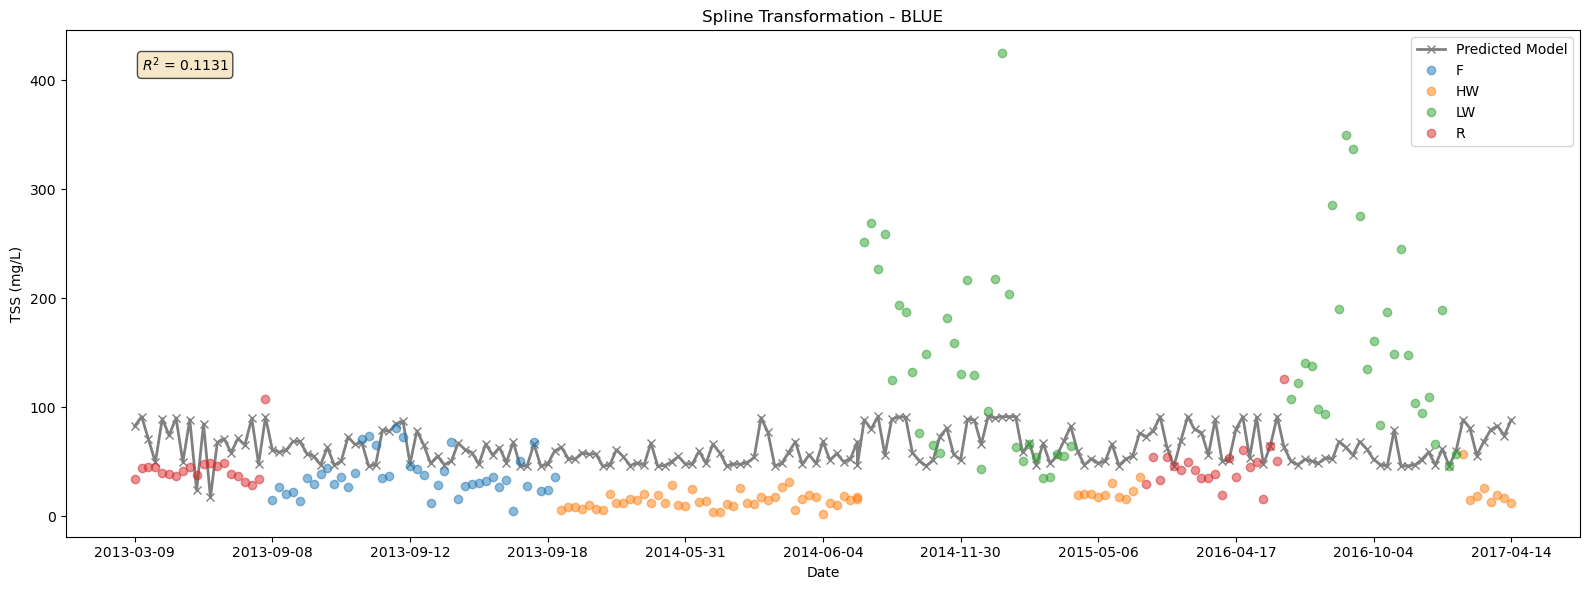


Spline Transformation - NIR/RED ratio Results
Training Metrics: {'r2': 0.4396701665621776, 'mae': 33.496817248784104, 'mse': 2840.0051703341687, 'mape': 1.210368369770554, 'exp_var': 0.4396701665621776}
CV Metrics: {'r2': 22.526234628756125, 'mae': 52.23998072919769, 'mse': 167738.79650617982, 'mape': 3.780887056074375, 'exp_var': 21.81599638050148}


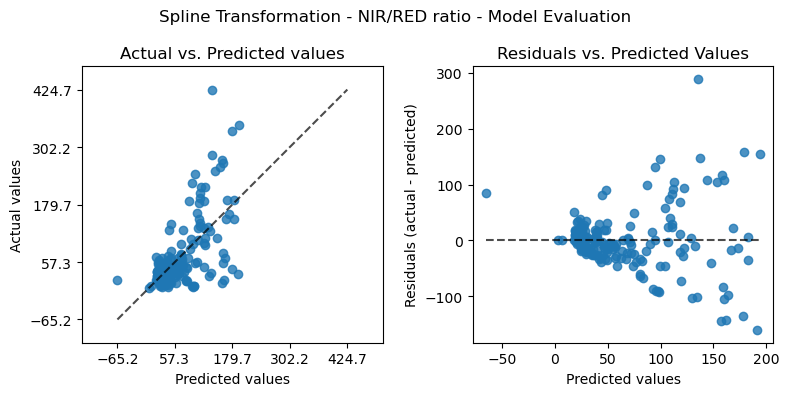

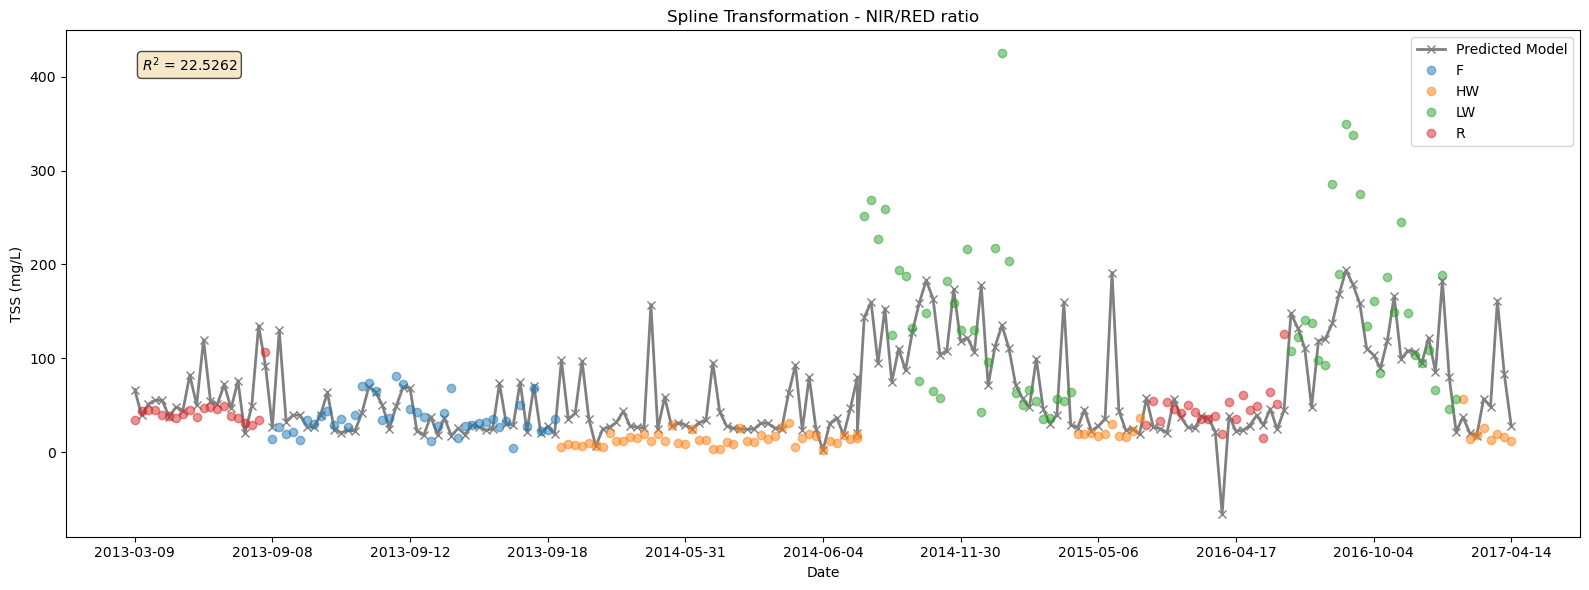


Spline Transformation - RED/NIR ratio Results
Training Metrics: {'r2': 0.31197348790298984, 'mae': 38.972583796765434, 'mse': 3487.229726273928, 'mape': 1.7325819519488248, 'exp_var': 0.31197348790298984}
CV Metrics: {'r2': 0.5697377124442001, 'mae': 42.31312270236934, 'mse': 4272.694829793438, 'mape': 2.18605831451625, 'exp_var': 0.5677620799407774}


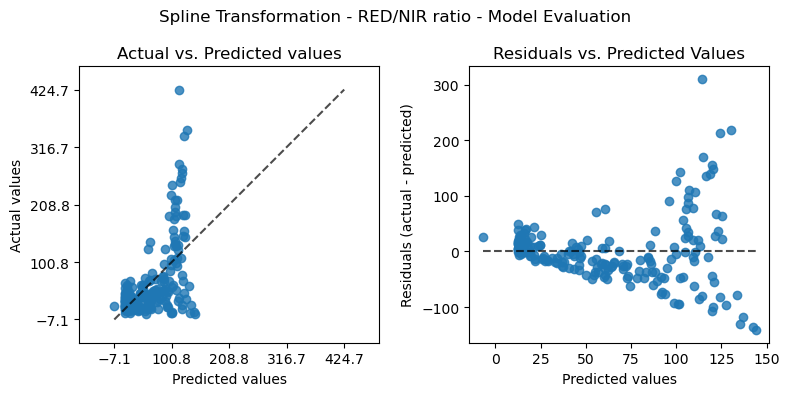

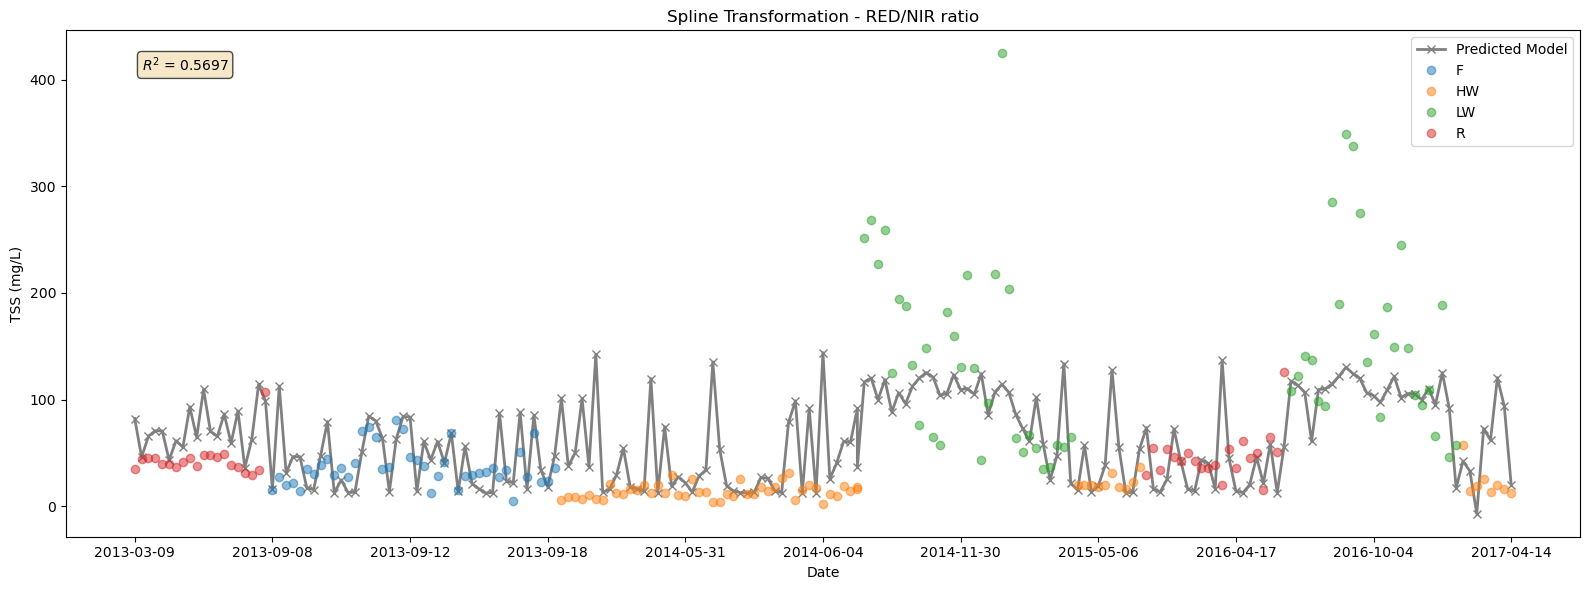

In [84]:
for model_key in MODEL_CONFIG.keys():
    model = get_model(model_key)
    title = (MODEL_CONFIG[model_key]['description'])
    # Feature Exploration
    for features in FEATURE_GROUPS['single_band'].values():
        X = df_subset[features['band']]
        model_fit, y_pred, metrics, cv_metrics = train_and_evaluate_model(
            model=model,
            X=X, y=y,
            model_name=f"{title} - {features['name']}",
            title = f"{title} - {features['name']}",
            df_data=df_subset
        )
        

# Multiple bands


Ordinary Least Squares - NIR and RED Results
Training Metrics: {'r2': 0.7100160834231855, 'mae': 26.104731941748675, 'mse': 1469.7697199863483, 'mape': 0.6724157514772289, 'exp_var': 0.7100160834231855}
CV Metrics: {'r2': 0.6639708572804073, 'mae': 25.975487055880194, 'mse': 1504.4952707058733, 'mape': 0.7260493704981308, 'exp_var': 0.6865799654069507}


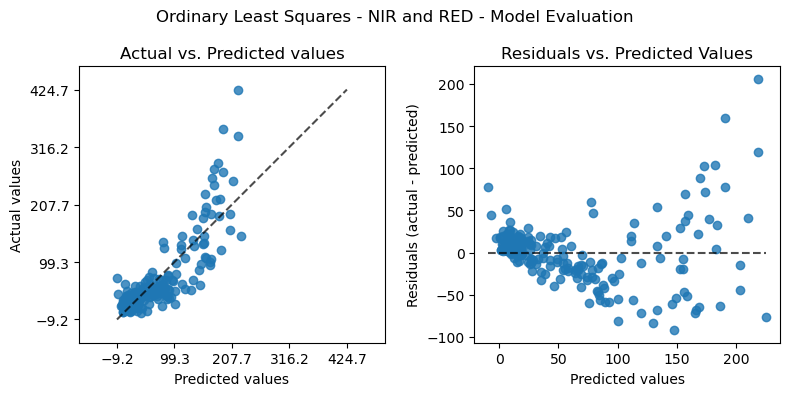

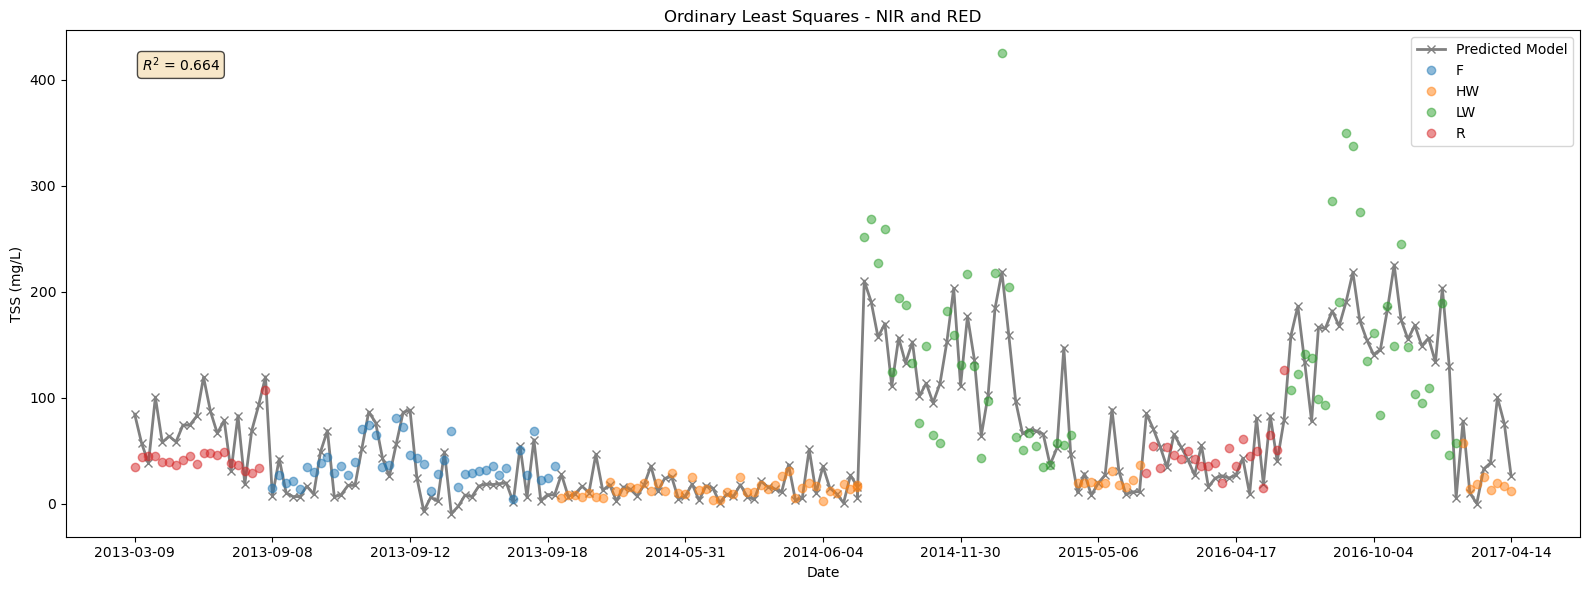


Ordinary Least Squares - All bands Results
Training Metrics: {'r2': 0.7190920234607749, 'mae': 25.166131532262657, 'mse': 1423.76874860445, 'mape': 0.6237839310455464, 'exp_var': 0.719092023460775}
CV Metrics: {'r2': 0.669180351490853, 'mae': 25.390201691685412, 'mse': 1500.1561339547184, 'mape': 0.685978665708947, 'exp_var': 0.6932699032432831}


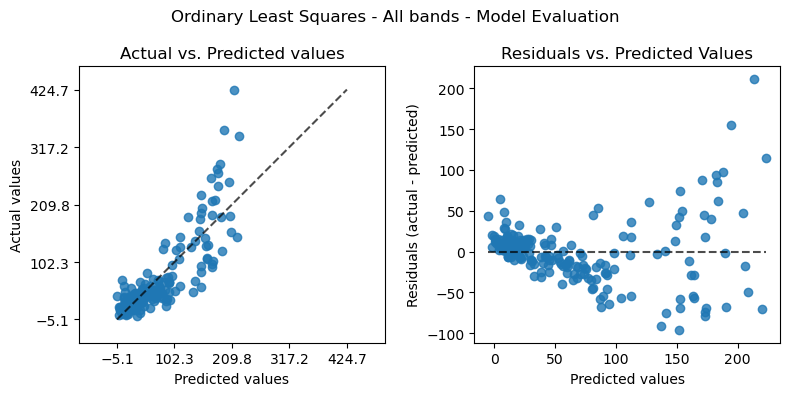

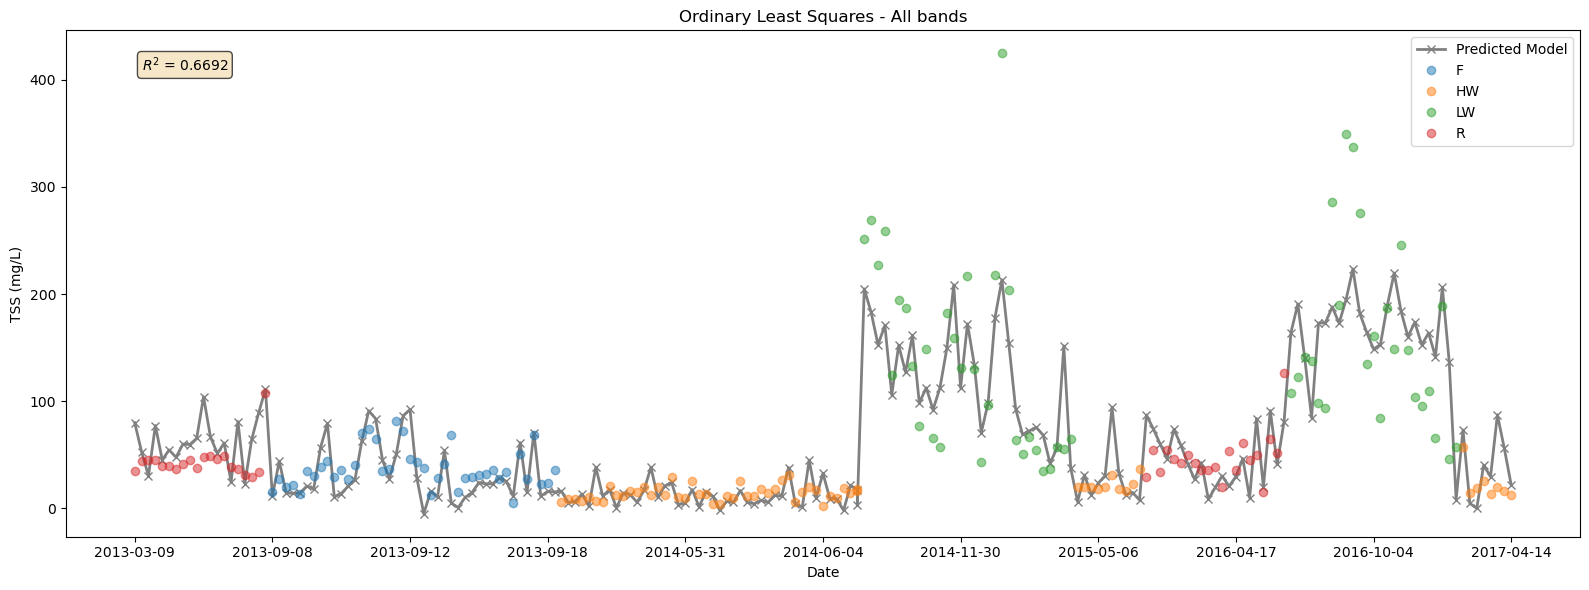


2nd Degree Polynomial - NIR and RED Results
Training Metrics: {'r2': 0.7886871945999461, 'mae': 19.98160815878431, 'mse': 1071.028926323562, 'mape': 0.41014760264319716, 'exp_var': 0.7886871945999461}
CV Metrics: {'r2': 0.7138020920887094, 'mae': 20.089226139576066, 'mse': 1192.0009048869365, 'mape': 0.4170255494284071, 'exp_var': 0.7219757710890068}


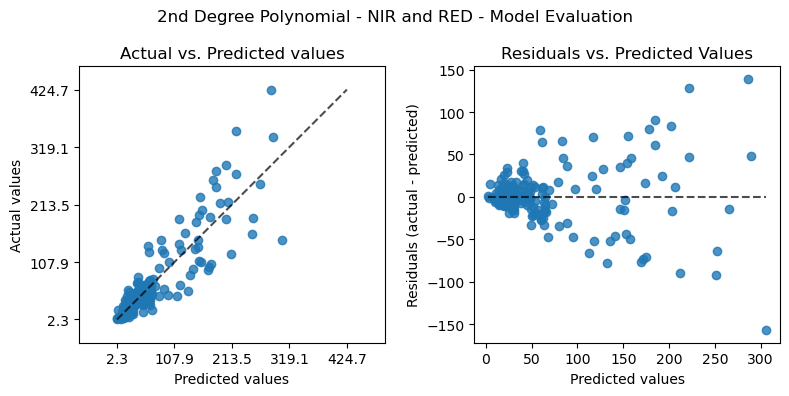

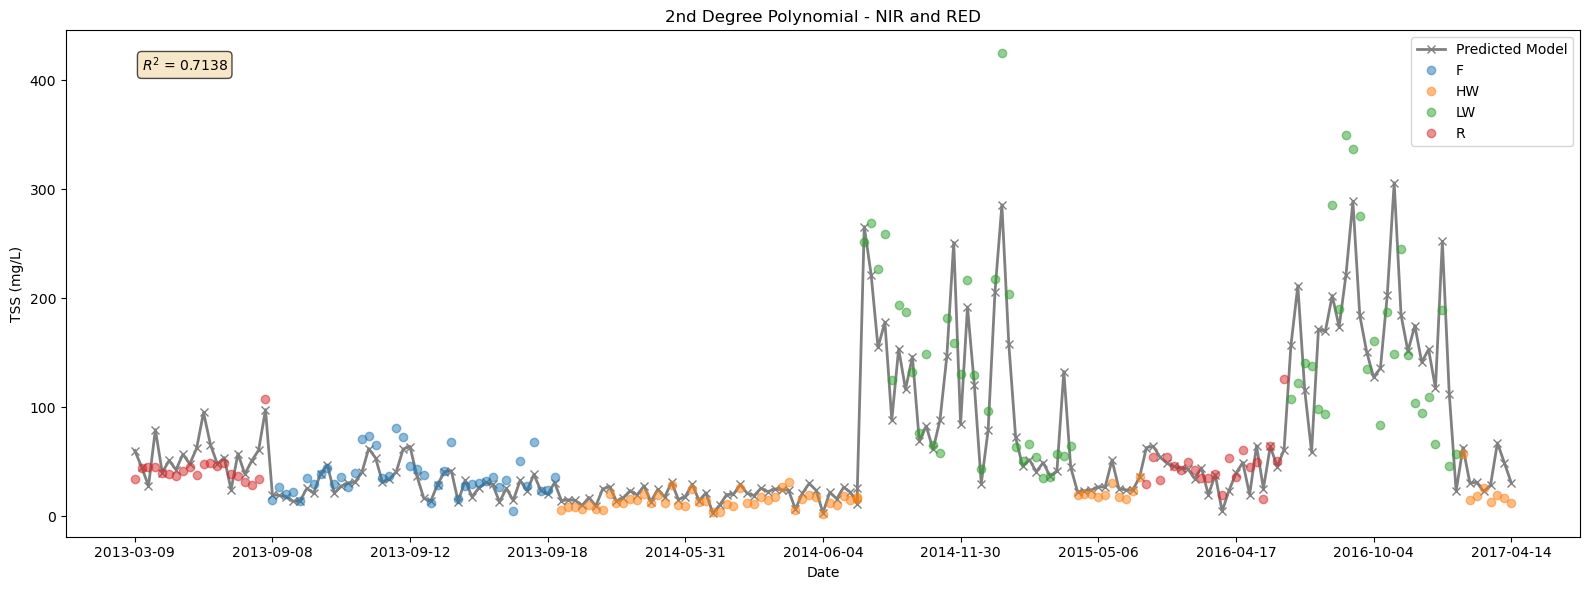


2nd Degree Polynomial - All bands Results
Training Metrics: {'r2': 0.8050219853326689, 'mae': 19.29152061783615, 'mse': 988.236814662052, 'mape': 0.4397574204251109, 'exp_var': 0.8050219853326689}
CV Metrics: {'r2': 0.710215619049632, 'mae': 20.63361319405339, 'mse': 1251.5946144509428, 'mape': 0.4796328111051082, 'exp_var': 0.7168765221455407}


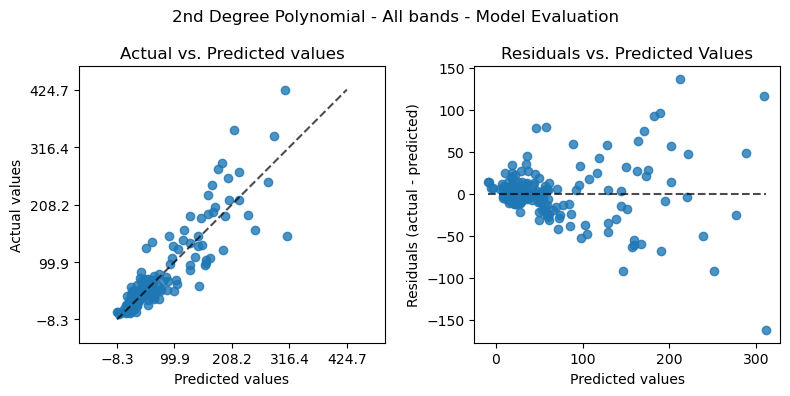

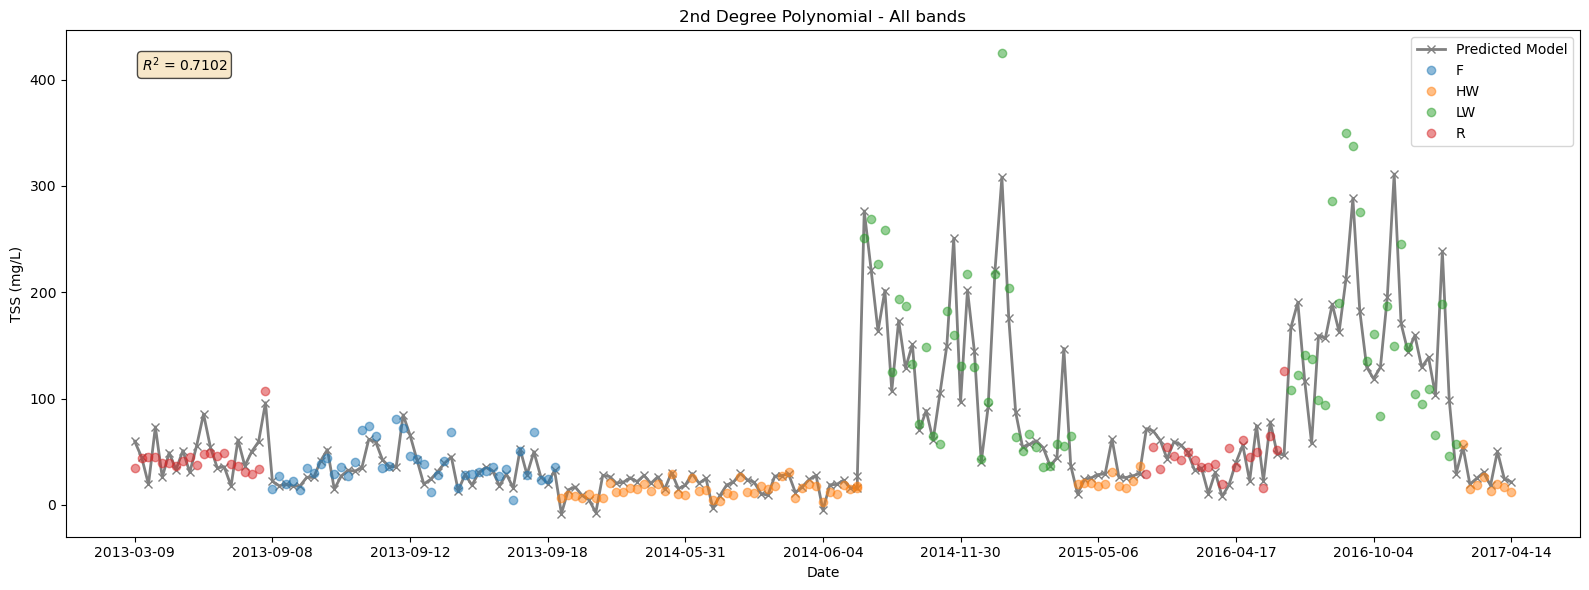


3rd Degree Polynomial - NIR and RED Results
Training Metrics: {'r2': 0.7897814560208677, 'mae': 20.059027315132226, 'mse': 1065.4827142397828, 'mape': 0.42382514695013035, 'exp_var': 0.7897814560208678}
CV Metrics: {'r2': 0.6905913106153797, 'mae': 21.305088042193347, 'mse': 1426.2681713514005, 'mape': 0.45955615981497794, 'exp_var': 0.690879052957666}


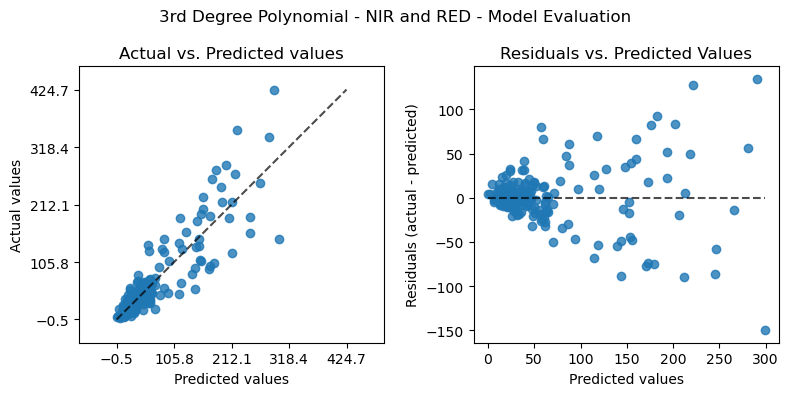

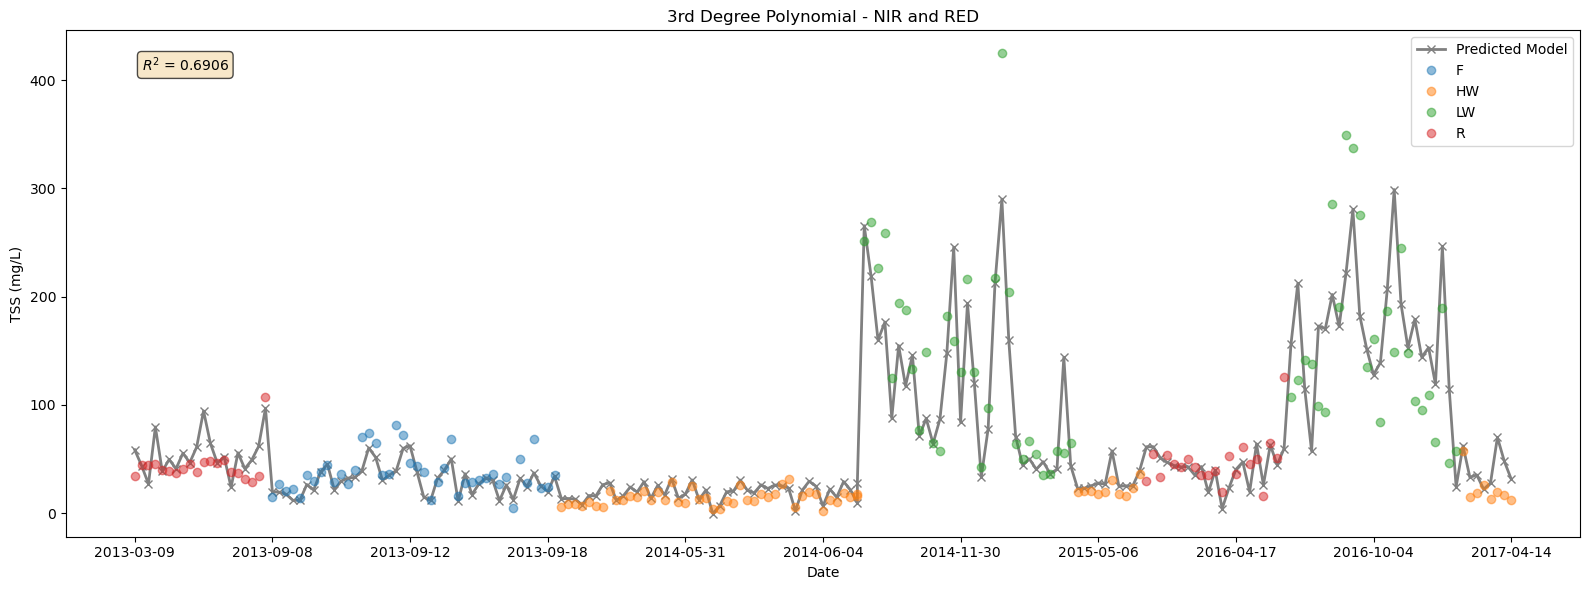


3rd Degree Polynomial - All bands Results
Training Metrics: {'r2': 0.8583633755314594, 'mae': 17.581943227800522, 'mse': 717.8785097545057, 'mape': 0.397330985351095, 'exp_var': 0.8583633755314594}
CV Metrics: {'r2': 0.6343599307868897, 'mae': 23.673113482875493, 'mse': 1659.6477774559814, 'mape': 0.5644561401374093, 'exp_var': 0.6438120748868493}


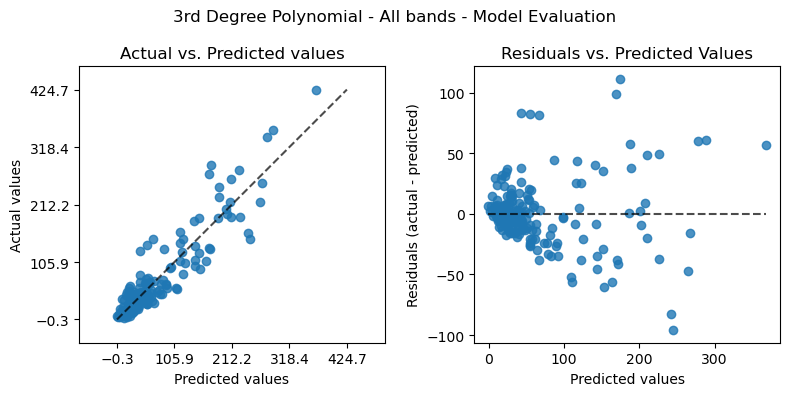

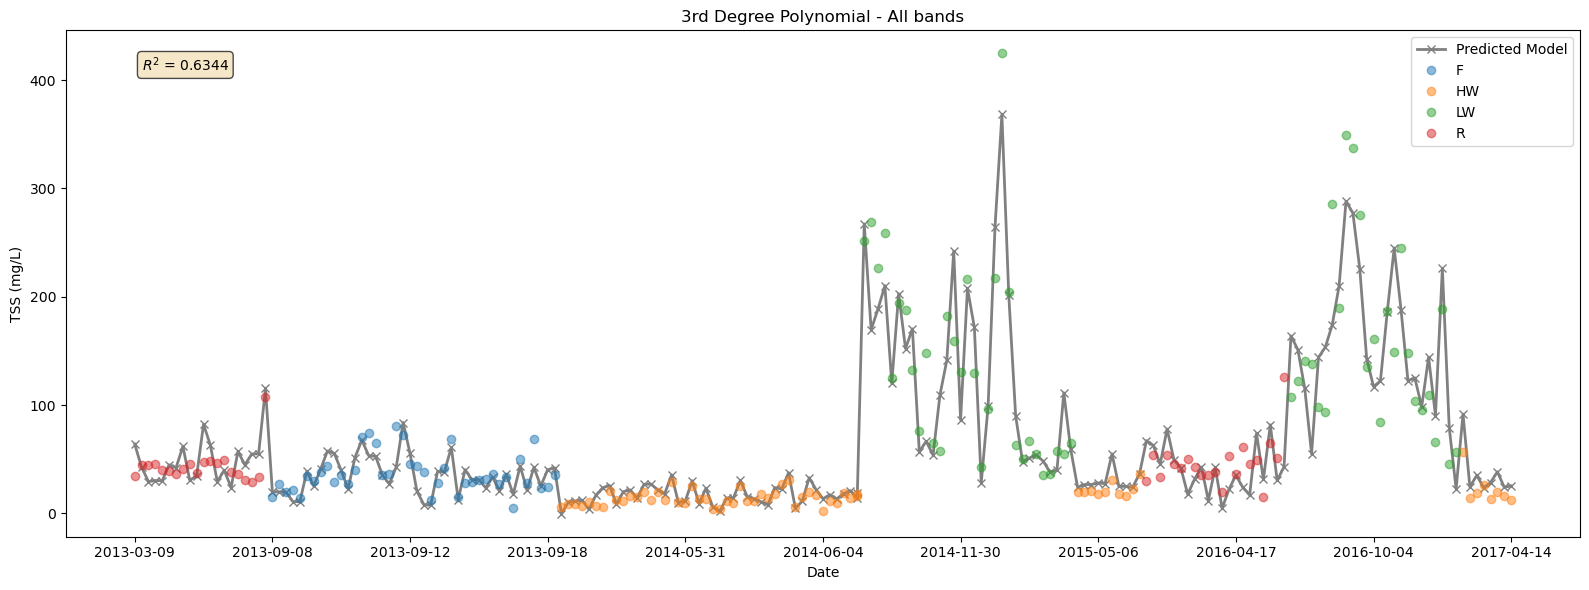


Spline Transformation - NIR and RED Results
Training Metrics: {'r2': 0.7983840330452833, 'mae': 20.187632490640386, 'mse': 1021.8809608267209, 'mape': 0.4200948924586379, 'exp_var': 0.7983840330452833}
CV Metrics: {'r2': 0.6905955553987463, 'mae': 21.71468872435755, 'mse': 1332.9094219274095, 'mape': 0.46232291850965923, 'exp_var': 0.696932902329524}


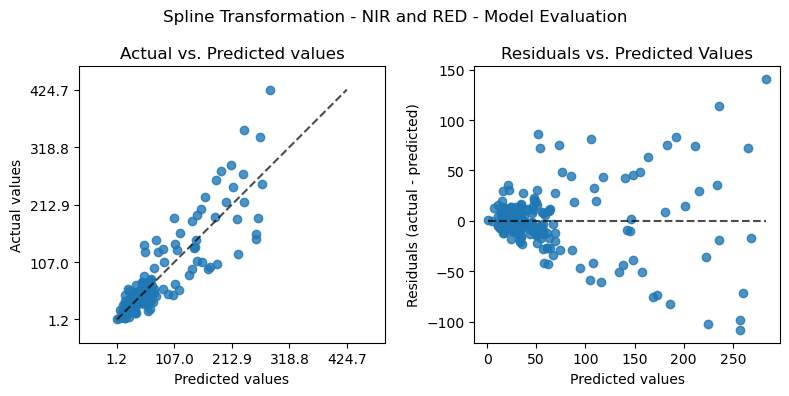

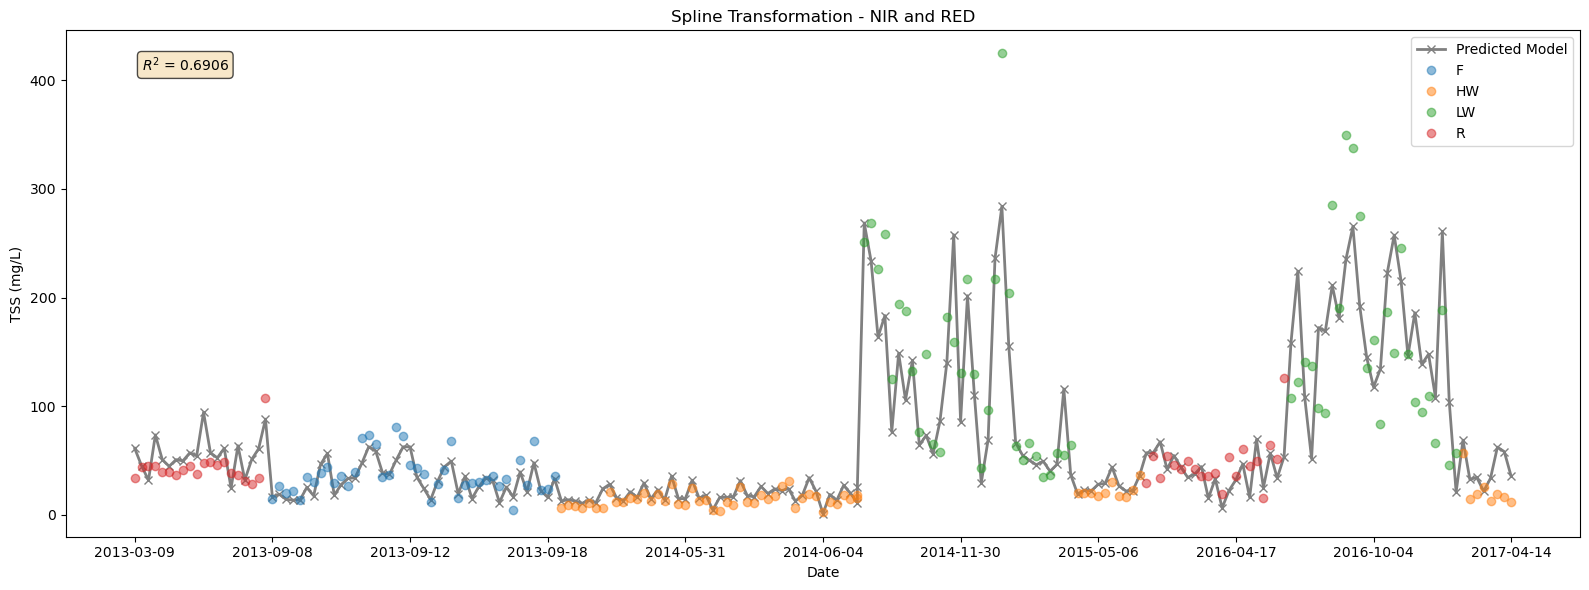


Spline Transformation - All bands Results
Training Metrics: {'r2': 0.8417326926551554, 'mae': 17.93517625699134, 'mse': 802.1703367041988, 'mape': 0.391827939064314, 'exp_var': 0.8417326926551554}
CV Metrics: {'r2': 0.6564230455212906, 'mae': 22.161266199579977, 'mse': 1469.849122287325, 'mape': 0.4953470634514421, 'exp_var': 0.674943328279052}


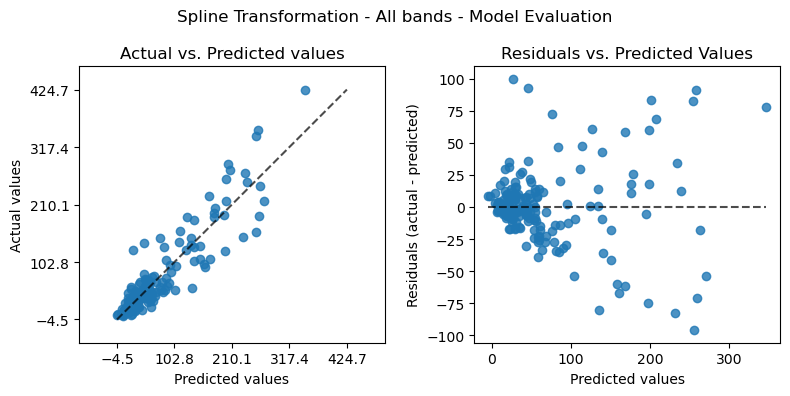

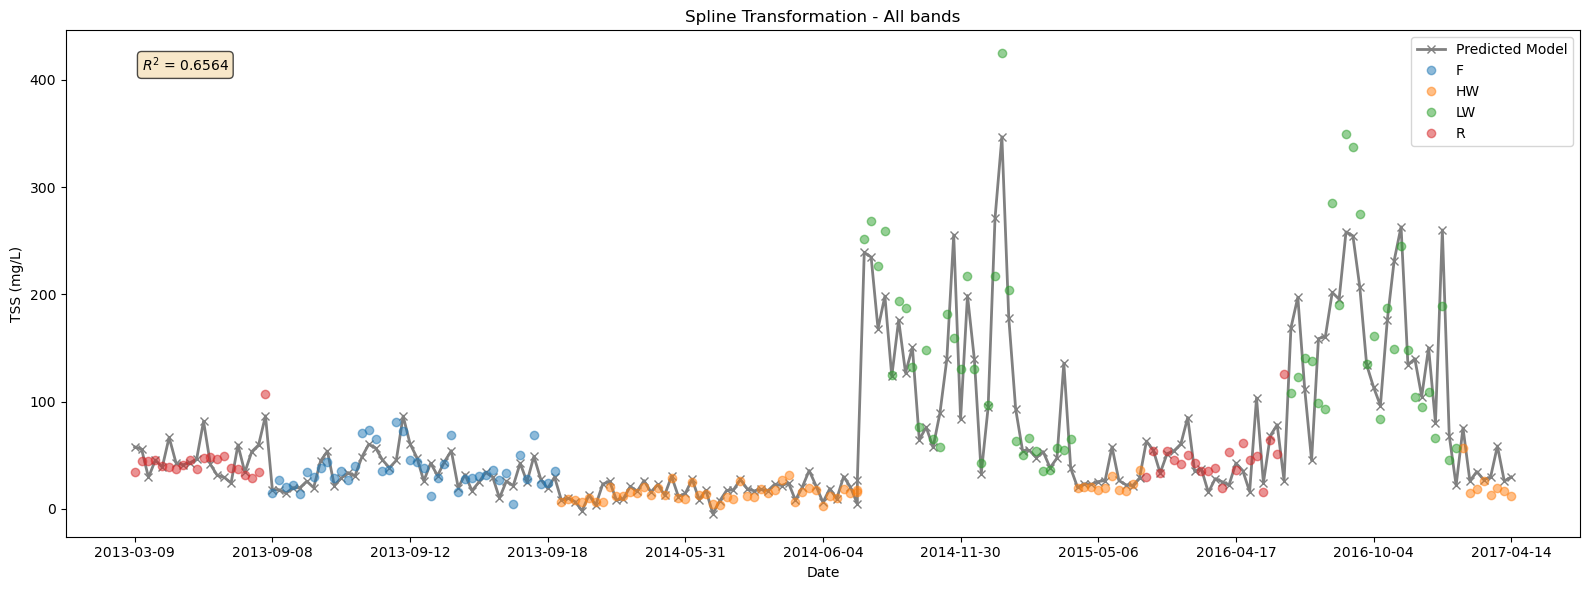

In [85]:
for model_key in MODEL_CONFIG.keys():
    model = get_model(model_key)
    title = (MODEL_CONFIG[model_key]['description'])
    # Feature Exploration
    for features in FEATURE_GROUPS['multi_band'].values():
        X = df_subset[features['band']]
        model_fit, y_pred, metrics, cv_metrics = train_and_evaluate_model(
            model=model,
            X=X, y=y,
            model_name=f"{title} - {features['name']}",
            title = f"{title} - {features['name']}",
            df_data=df_subset
        )